In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [4]:
T_initial = 2500
T_val = 100
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 1000000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+10)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

unique_irewards = np.sort(np.unique(irewards))
print(unique_irewards)
# Build mapping: real value → class index
val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

# Assign class indices
irewards_class = np.array([val_to_class[y] for y in irewards])

Y_class, counts = np.unique(irewards_class, return_counts=True)
priors = counts / counts.sum()
print(priors)

X_train = new_state_oh[:T_initial,:]
Y_train = irewards_class[:T_initial]

X_val = new_state_oh[:T_initial+T_val,:]
Y_val = irewards_class[:T_initial+T_val]
# print(Y_train)




[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
[0.856723 0.014284 0.014496 0.014349 0.014401 0.014488 0.014138 0.01436
 0.014194 0.014256 0.014311]


# PAFV - MLP - Classifier

In [120]:
batch_size_train = 32
batch_size_val = 32
train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.int64)))
val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.int64)))
train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

In [121]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), n_classes=11, p_dropout=0.2):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, n_classes)]  # logits (no softmax here)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x) 


def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = torch.nn.CrossEntropyLoss(weight=torch.from_numpy(priors.astype(np.float32)).to(device))

    best_val = -1
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            total_acc  += accuracy(logits.detach(), yb)
            n_batches  += 1

        # validation
        model.eval()
        val_acc = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_acc += accuracy(logits, yb)
                n_val += 1
        val_acc /= max(1, n_val)

        tr_loss = total_loss / max(1, n_batches)
        tr_acc  = total_acc  / max(1, n_batches)
        print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} | train acc {tr_acc:.3f} | val acc {val_acc:.3f}")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_proba(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(device).float())
        return logits.softmax(dim=1).cpu()  # (N, 11)

In [123]:
model = MLP(input_dim=X_train.shape[1], hidden=(128,256), n_classes=11, p_dropout=0.1)
model = train_model(model, train_loader, val_loader, epochs=300, lr=3e-4)

Epoch 01 | train loss 0.9116 | train acc 0.818 | val acc 0.842
Epoch 02 | train loss 0.0385 | train acc 0.838 | val acc 0.842
Epoch 03 | train loss 0.0314 | train acc 0.838 | val acc 0.842
Epoch 04 | train loss 0.0293 | train acc 0.841 | val acc 0.842
Epoch 05 | train loss 0.0287 | train acc 0.841 | val acc 0.842
Epoch 06 | train loss 0.0294 | train acc 0.835 | val acc 0.842
Epoch 07 | train loss 0.0280 | train acc 0.838 | val acc 0.842
Epoch 08 | train loss 0.0285 | train acc 0.835 | val acc 0.842
Epoch 09 | train loss 0.0268 | train acc 0.841 | val acc 0.842
Epoch 10 | train loss 0.0265 | train acc 0.838 | val acc 0.842
Epoch 11 | train loss 0.0261 | train acc 0.838 | val acc 0.842
Epoch 12 | train loss 0.0253 | train acc 0.841 | val acc 0.842
Epoch 13 | train loss 0.0261 | train acc 0.835 | val acc 0.842
Epoch 14 | train loss 0.0241 | train acc 0.841 | val acc 0.842
Epoch 15 | train loss 0.0244 | train acc 0.841 | val acc 0.842
Epoch 16 | train loss 0.0234 | train acc 0.841 | val ac

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_69615/2465357891.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_69615/2465357891.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.1577468786780355


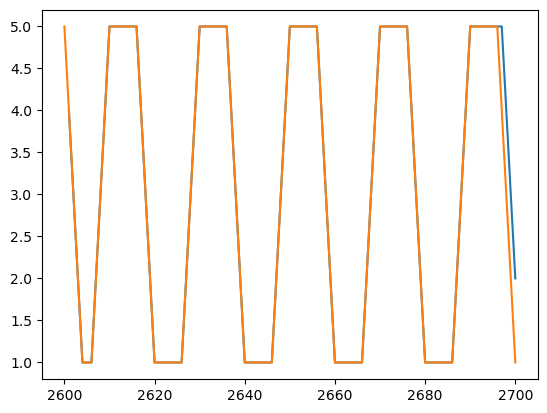

In [ ]:
T = T_initial+T_val
gamma = 0.5
t_prime = 6
current_state = np.random.choice([int(i) for i in range(7)],size = 1)
future_states = [current_state.item()]
# print(current_state)
FUTURE_STATE = []
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        pred_prob = predict_proba(model, features)
        pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
        irewards_pred[:,i] = pred_val.reshape(-1)
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state

# print(T,future_states,len(future_states))
FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

# PAFM - Regressor - MLP

In [5]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), p_dropout=0.2, use_sigmoid=True):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        if use_sigmoid:           # keep preds in [0,1] since y is normalized
            layers += [nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)        # (N, 1)

def mse_loss(pred, target, eps=1e-12):
    # return torch.sqrt(nn.functional.mse_loss(pred, target) + eps)
    return nn.functional.mse_loss(pred, target)

def train_regressor(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_tr = float("inf")
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot_rmse, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb = xb.to(device).float()
            yb = yb.to(device).float().view(-1, 1)  # ensure (N,1)

            opt.zero_grad()
            preds = model(xb)
            loss = mse_loss(preds, yb)
            loss.backward()
            opt.step()

            tot_rmse += loss.item()
            n_batches += 1

        # validation
        model.eval()
        val_rmse, m = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device).float()
                yb = yb.to(device).float().view(-1, 1)
                preds = model(xb)
                val_rmse += mse_loss(preds, yb).item()
                m += 1
        val_rmse /= max(1, m)
        tr_rmse = tot_rmse / max(1, n_batches)

        print(f"Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

        if tr_rmse <= best_tr:
            best_tr = tr_rmse
            if val_rmse <= best_val:
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        if isinstance(X, torch.Tensor):
            X_t = X.to(device).float()
        else:
            import numpy as np
            X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).to(device)
        preds = model(X_t).cpu().squeeze(1)
    return preds

In [6]:
T_initial = 2048
T_val = 100
X_train = new_state_oh[:T_initial,:]
Y_train = np.array(irewards[:T_initial]).reshape(-1,1)/ 10.0 

X_val = new_state_oh[:T_initial+T_val,:]
Y_val = np.array(irewards[:T_initial+T_val]).reshape(-1,1)/ 10.0 
print(X_train.shape,Y_train.shape)

NameError: name 'new_state_oh' is not defined

In [249]:
batch_size_train = 128
batch_size_val = 128
train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

In [250]:
model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=(192,128), p_dropout=0.1, use_sigmoid=True)
model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=3000, lr=3e-4,weight_decay = 1e-5)

Epoch 01 | train RMSE 0.4424 | val RMSE 0.3749
Epoch 02 | train RMSE 0.3158 | val RMSE 0.2526
Epoch 03 | train RMSE 0.2121 | val RMSE 0.1779
Epoch 04 | train RMSE 0.1656 | val RMSE 0.1589
Epoch 05 | train RMSE 0.1557 | val RMSE 0.1549
Epoch 06 | train RMSE 0.1522 | val RMSE 0.1533
Epoch 07 | train RMSE 0.1510 | val RMSE 0.1519
Epoch 08 | train RMSE 0.1484 | val RMSE 0.1505
Epoch 09 | train RMSE 0.1471 | val RMSE 0.1489
Epoch 10 | train RMSE 0.1469 | val RMSE 0.1472
Epoch 11 | train RMSE 0.1415 | val RMSE 0.1454
Epoch 12 | train RMSE 0.1403 | val RMSE 0.1436
Epoch 13 | train RMSE 0.1399 | val RMSE 0.1416
Epoch 14 | train RMSE 0.1380 | val RMSE 0.1396
Epoch 15 | train RMSE 0.1372 | val RMSE 0.1375
Epoch 16 | train RMSE 0.1352 | val RMSE 0.1353
Epoch 17 | train RMSE 0.1309 | val RMSE 0.1330
Epoch 18 | train RMSE 0.1296 | val RMSE 0.1308
Epoch 19 | train RMSE 0.1275 | val RMSE 0.1282
Epoch 20 | train RMSE 0.1234 | val RMSE 0.1256
Epoch 21 | train RMSE 0.1206 | val RMSE 0.1224
Epoch 22 | tr

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_69615/198784847.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  irewards_pred[:,i] = pred_val.reshape(-1)
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_69615/198784847.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0972006399999998


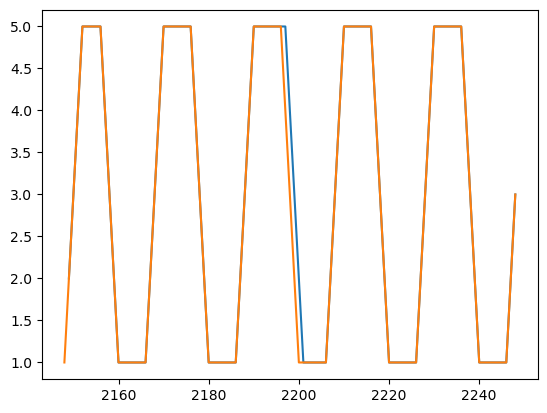

In [252]:
T = T_initial+T_val
gamma = 0.5
t_prime = 6
current_state = np.random.choice([int(i) for i in range(7)],size = 1)
future_states = [current_state.item()]
# print(current_state)
FUTURE_STATE = []
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        # pred_prob = predict_proba(model, features)
        # pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
        pred_val = predict(model_reg, features)*10
        irewards_pred[:,i] = pred_val.reshape(-1)
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state

# print(T,future_states,len(future_states))
FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

# PVFM - MLP - Regressor

In [4]:
DELTA_t = 10
t_prime = 6
# Ts = [1000,5000,10000,20000,40000,80000]
Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(1):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T_initial in Ts:
        # n_seq = int(T/(DELTA_t+1))
        T_val = int(T_initial*0.2)
        T= T_val + T_initial
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(5000)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:]
        
        X_train = STATES_arr[:T_initial,:]
        Y_train = np.array(REWARDS_arr[:T_initial]).reshape(-1,1)/ 10

        X_val = STATES_arr[T_initial:T,:]
        Y_val = np.array(REWARDS_arr[T_initial:T]).reshape(-1,1)/ 10
        print(X_train.shape,Y_train.shape,X_val.shape,Y_val.shape)
        epochs = 200
        weight_decay = 1e-6
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            # epochs = 100
            hidden_layers = (192,128)
        elif T_initial == 10000:
            # learning_rate = 3e-4
            batch_size_train = 128
            hidden_layers = (512,256)
        elif T_initial == 20000:
            # learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            # learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            # learning_rate = 1e-4
            batch_size_train = 512
            # hidden_layers = (1024,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_initial+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_initial+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*10
                prewards_pred[:,i] = pred_val
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T_initial+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T_initial+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T_initial, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T_initial+1,T_initial+101),future_states[1:])
        plt.plot(np.arange(T_initial,T_initial+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    # np.savez(
    #     f"../results/PVFM/NN_Yuxin/NN_SameStructure_optimal_oh_w_time1000_80000_w_lookahead{t_prime}_reps{rep}.npz",
    #     future_states =FUTURE_STATE_arr
    #     )



96000
(80000, 57) (80000, 1) (16000, 57) (16000, 1)


NameError: name 'MLPRegressor' is not defined

1200
(1000, 57) (1000, 1) (200, 57) (200, 1)
Epoch 01 | train MSE 0.108657 | val MSE 0.062129
Epoch 02 | train MSE 0.037128 | val MSE 0.029791
Epoch 03 | train MSE 0.027870 | val MSE 0.029281
Epoch 04 | train MSE 0.026610 | val MSE 0.028440
Epoch 05 | train MSE 0.025513 | val MSE 0.027764
Epoch 06 | train MSE 0.025414 | val MSE 0.027078
Epoch 07 | train MSE 0.023971 | val MSE 0.026497
Epoch 08 | train MSE 0.024248 | val MSE 0.025816
Epoch 09 | train MSE 0.021836 | val MSE 0.025322
Epoch 10 | train MSE 0.021919 | val MSE 0.024748
Epoch 11 | train MSE 0.021200 | val MSE 0.024347
Epoch 12 | train MSE 0.020001 | val MSE 0.023843
Epoch 13 | train MSE 0.018943 | val MSE 0.023563
Epoch 14 | train MSE 0.018421 | val MSE 0.023167
Epoch 15 | train MSE 0.018149 | val MSE 0.023164
Epoch 16 | train MSE 0.017091 | val MSE 0.023072
Epoch 17 | train MSE 0.016654 | val MSE 0.023176
Epoch 18 | train MSE 0.016244 | val MSE 0.023012
Epoch 19 | train MSE 0.015727 | val MSE 0.023187
Epoch 20 | train MSE 0.0

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/50387583.py:108: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prewards_pred[:,i] = pred_val


1.4797777856532703


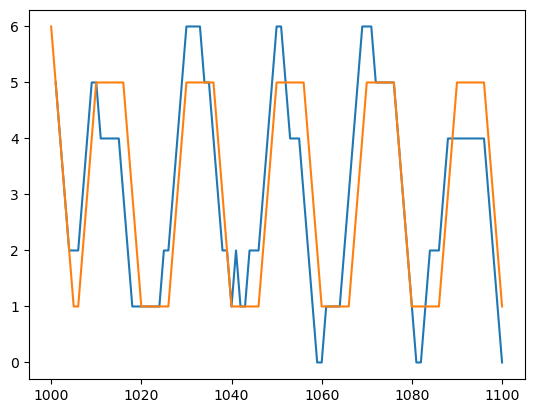

6000
(5000, 57) (5000, 1) (1000, 57) (1000, 1)
Epoch 01 | train MSE 0.044593 | val MSE 0.022306
Epoch 02 | train MSE 0.023898 | val MSE 0.020218
Epoch 03 | train MSE 0.021176 | val MSE 0.018576
Epoch 04 | train MSE 0.019256 | val MSE 0.017966
Epoch 05 | train MSE 0.018148 | val MSE 0.017656
Epoch 06 | train MSE 0.017451 | val MSE 0.017290
Epoch 07 | train MSE 0.016548 | val MSE 0.016512
Epoch 08 | train MSE 0.015306 | val MSE 0.015223
Epoch 09 | train MSE 0.013328 | val MSE 0.012921
Epoch 10 | train MSE 0.010983 | val MSE 0.010016
Epoch 11 | train MSE 0.008489 | val MSE 0.006207
Epoch 12 | train MSE 0.005701 | val MSE 0.003854
Epoch 13 | train MSE 0.004354 | val MSE 0.002716
Epoch 14 | train MSE 0.003505 | val MSE 0.002101
Epoch 15 | train MSE 0.003100 | val MSE 0.001755
Epoch 16 | train MSE 0.002709 | val MSE 0.001599
Epoch 17 | train MSE 0.002528 | val MSE 0.001447
Epoch 18 | train MSE 0.002245 | val MSE 0.001204
Epoch 19 | train MSE 0.002194 | val MSE 0.001153
Epoch 20 | train MSE 0

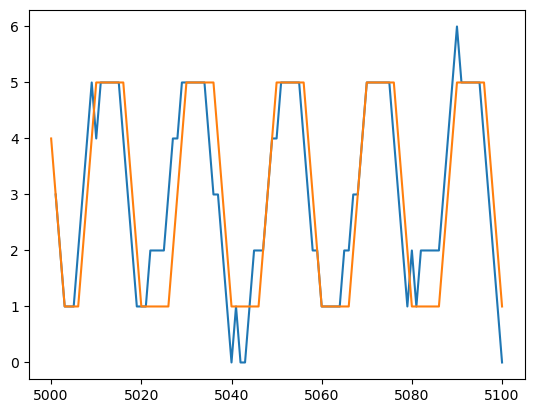

12000
(10000, 57) (10000, 1) (2000, 57) (2000, 1)
Epoch 01 | train MSE 0.039729 | val MSE 0.024081
Epoch 02 | train MSE 0.022607 | val MSE 0.020246
Epoch 03 | train MSE 0.019543 | val MSE 0.018808
Epoch 04 | train MSE 0.017609 | val MSE 0.017105
Epoch 05 | train MSE 0.014880 | val MSE 0.012010
Epoch 06 | train MSE 0.008636 | val MSE 0.004051
Epoch 07 | train MSE 0.004287 | val MSE 0.001963
Epoch 08 | train MSE 0.002699 | val MSE 0.001056
Epoch 09 | train MSE 0.001987 | val MSE 0.000800
Epoch 10 | train MSE 0.001718 | val MSE 0.000677
Epoch 11 | train MSE 0.001470 | val MSE 0.000561
Epoch 12 | train MSE 0.001336 | val MSE 0.000498
Epoch 13 | train MSE 0.001189 | val MSE 0.000458
Epoch 14 | train MSE 0.001139 | val MSE 0.000428
Epoch 15 | train MSE 0.001088 | val MSE 0.000359
Epoch 16 | train MSE 0.000944 | val MSE 0.000312
Epoch 17 | train MSE 0.000949 | val MSE 0.000300
Epoch 18 | train MSE 0.000857 | val MSE 0.000276
Epoch 19 | train MSE 0.000825 | val MSE 0.000262
Epoch 20 | train MS

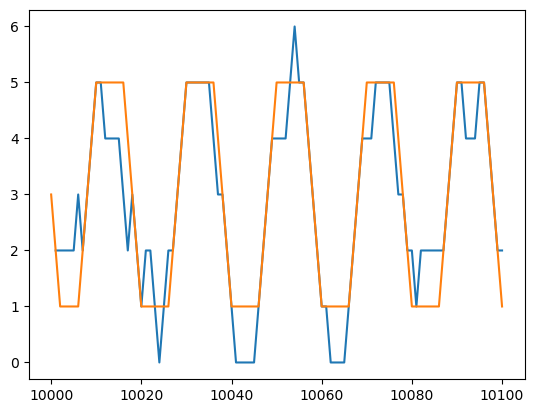

24000
(20000, 57) (20000, 1) (4000, 57) (4000, 1)
Epoch 01 | train MSE 0.042080 | val MSE 0.023691
Epoch 02 | train MSE 0.022723 | val MSE 0.019081
Epoch 03 | train MSE 0.019363 | val MSE 0.017312
Epoch 04 | train MSE 0.016822 | val MSE 0.013760
Epoch 05 | train MSE 0.010159 | val MSE 0.004404
Epoch 06 | train MSE 0.004369 | val MSE 0.001949
Epoch 07 | train MSE 0.002631 | val MSE 0.000902
Epoch 08 | train MSE 0.001802 | val MSE 0.000610
Epoch 09 | train MSE 0.001519 | val MSE 0.000527
Epoch 10 | train MSE 0.001297 | val MSE 0.000451
Epoch 11 | train MSE 0.001169 | val MSE 0.000370
Epoch 12 | train MSE 0.001088 | val MSE 0.000325
Epoch 13 | train MSE 0.000993 | val MSE 0.000280
Epoch 14 | train MSE 0.000924 | val MSE 0.000250
Epoch 15 | train MSE 0.000826 | val MSE 0.000217
Epoch 16 | train MSE 0.000811 | val MSE 0.000197
Epoch 17 | train MSE 0.000751 | val MSE 0.000182
Epoch 18 | train MSE 0.000716 | val MSE 0.000169
Epoch 19 | train MSE 0.000677 | val MSE 0.000151
Epoch 20 | train MS

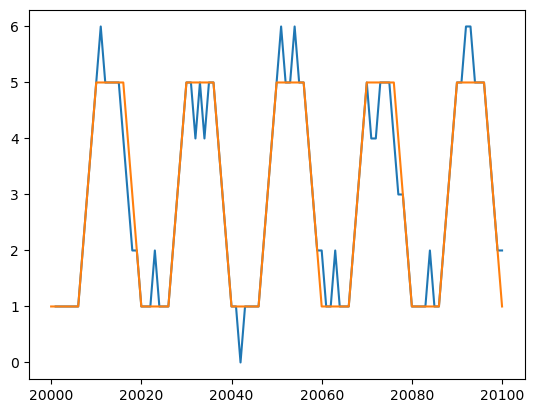

48000
(40000, 57) (40000, 1) (8000, 57) (8000, 1)
Epoch 01 | train MSE 0.032961 | val MSE 0.019511
Epoch 02 | train MSE 0.018703 | val MSE 0.016009
Epoch 03 | train MSE 0.009922 | val MSE 0.002692
Epoch 04 | train MSE 0.002546 | val MSE 0.000610
Epoch 05 | train MSE 0.001401 | val MSE 0.000395
Epoch 06 | train MSE 0.001121 | val MSE 0.000282
Epoch 07 | train MSE 0.000936 | val MSE 0.000223
Epoch 08 | train MSE 0.000843 | val MSE 0.000175
Epoch 09 | train MSE 0.000753 | val MSE 0.000153
Epoch 10 | train MSE 0.000692 | val MSE 0.000122
Epoch 11 | train MSE 0.000635 | val MSE 0.000108
Epoch 12 | train MSE 0.000576 | val MSE 0.000104
Epoch 13 | train MSE 0.000556 | val MSE 0.000091
Epoch 14 | train MSE 0.000529 | val MSE 0.000083
Epoch 15 | train MSE 0.000504 | val MSE 0.000089
Epoch 16 | train MSE 0.000485 | val MSE 0.000075
Epoch 17 | train MSE 0.000460 | val MSE 0.000091
Epoch 18 | train MSE 0.000439 | val MSE 0.000066
Epoch 19 | train MSE 0.000415 | val MSE 0.000060
Epoch 20 | train MS

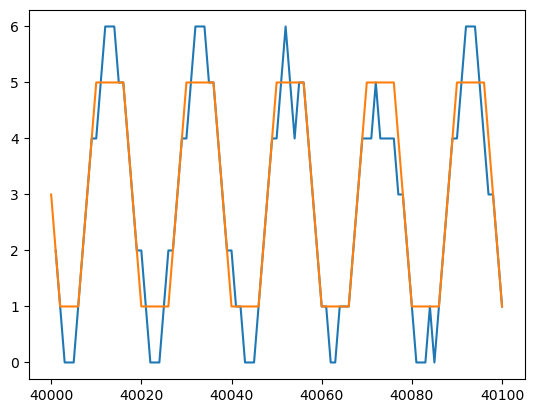

96000
(80000, 57) (80000, 1) (16000, 57) (16000, 1)
Epoch 01 | train MSE 0.025633 | val MSE 0.015415
Epoch 02 | train MSE 0.006336 | val MSE 0.000650
Epoch 03 | train MSE 0.001313 | val MSE 0.000307
Epoch 04 | train MSE 0.000901 | val MSE 0.000180
Epoch 05 | train MSE 0.000714 | val MSE 0.000131
Epoch 06 | train MSE 0.000597 | val MSE 0.000090
Epoch 07 | train MSE 0.000509 | val MSE 0.000073
Epoch 08 | train MSE 0.000463 | val MSE 0.000070
Epoch 09 | train MSE 0.000414 | val MSE 0.000054
Epoch 10 | train MSE 0.000377 | val MSE 0.000055
Epoch 11 | train MSE 0.000354 | val MSE 0.000047
Epoch 12 | train MSE 0.000333 | val MSE 0.000037
Epoch 13 | train MSE 0.000310 | val MSE 0.000030
Epoch 14 | train MSE 0.000295 | val MSE 0.000035
Epoch 15 | train MSE 0.000274 | val MSE 0.000036
Epoch 16 | train MSE 0.000262 | val MSE 0.000026
Epoch 17 | train MSE 0.000249 | val MSE 0.000025
Epoch 18 | train MSE 0.000241 | val MSE 0.000032
Epoch 19 | train MSE 0.000227 | val MSE 0.000030
Epoch 20 | train 

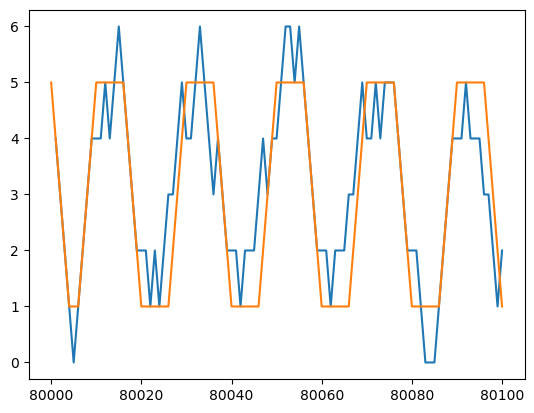

1200
(1000, 57) (1000, 1) (200, 57) (200, 1)
Epoch 01 | train MSE 0.108393 | val MSE 0.061287
Epoch 02 | train MSE 0.038774 | val MSE 0.025593
Epoch 03 | train MSE 0.026242 | val MSE 0.025187
Epoch 04 | train MSE 0.026339 | val MSE 0.024576
Epoch 05 | train MSE 0.024804 | val MSE 0.024110
Epoch 06 | train MSE 0.024256 | val MSE 0.023542
Epoch 07 | train MSE 0.024319 | val MSE 0.023105
Epoch 08 | train MSE 0.024151 | val MSE 0.022645
Epoch 09 | train MSE 0.022775 | val MSE 0.022264
Epoch 10 | train MSE 0.022221 | val MSE 0.021866
Epoch 11 | train MSE 0.021915 | val MSE 0.021602
Epoch 12 | train MSE 0.021280 | val MSE 0.021051
Epoch 13 | train MSE 0.020471 | val MSE 0.020728
Epoch 14 | train MSE 0.020170 | val MSE 0.020367
Epoch 15 | train MSE 0.019038 | val MSE 0.020299
Epoch 16 | train MSE 0.018991 | val MSE 0.019979
Epoch 17 | train MSE 0.018382 | val MSE 0.019735
Epoch 18 | train MSE 0.017592 | val MSE 0.019474
Epoch 19 | train MSE 0.017838 | val MSE 0.019455
Epoch 20 | train MSE 0.0

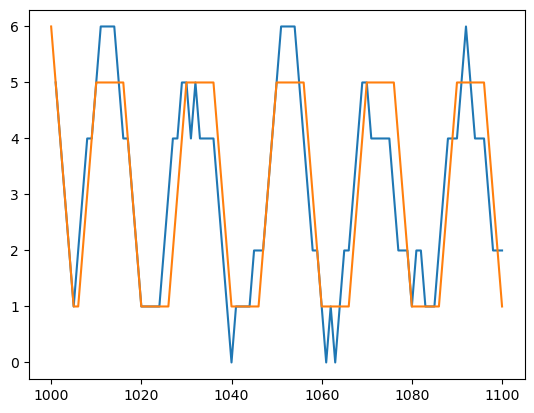

6000
(5000, 57) (5000, 1) (1000, 57) (1000, 1)
Epoch 01 | train MSE 0.049148 | val MSE 0.026111
Epoch 02 | train MSE 0.024238 | val MSE 0.023286
Epoch 03 | train MSE 0.021720 | val MSE 0.020890
Epoch 04 | train MSE 0.019862 | val MSE 0.020125
Epoch 05 | train MSE 0.018771 | val MSE 0.019200
Epoch 06 | train MSE 0.018052 | val MSE 0.018585
Epoch 07 | train MSE 0.016969 | val MSE 0.017958
Epoch 08 | train MSE 0.015827 | val MSE 0.017138
Epoch 09 | train MSE 0.014754 | val MSE 0.015758
Epoch 10 | train MSE 0.012943 | val MSE 0.013901
Epoch 11 | train MSE 0.010781 | val MSE 0.011076
Epoch 12 | train MSE 0.008686 | val MSE 0.007889
Epoch 13 | train MSE 0.006321 | val MSE 0.005461
Epoch 14 | train MSE 0.005003 | val MSE 0.004055
Epoch 15 | train MSE 0.004067 | val MSE 0.003263
Epoch 16 | train MSE 0.003558 | val MSE 0.003300
Epoch 17 | train MSE 0.003114 | val MSE 0.002726
Epoch 18 | train MSE 0.002809 | val MSE 0.002157
Epoch 19 | train MSE 0.002495 | val MSE 0.001756
Epoch 20 | train MSE 0

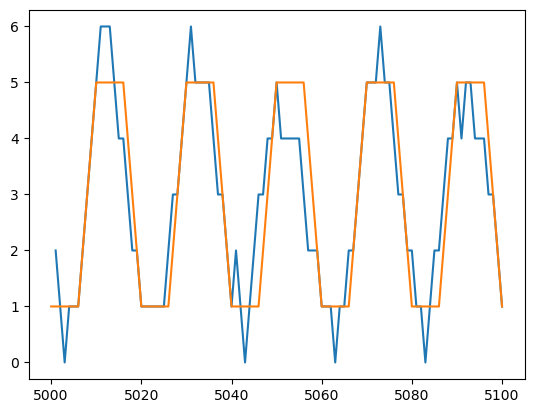

12000
(10000, 57) (10000, 1) (2000, 57) (2000, 1)
Epoch 01 | train MSE 0.039051 | val MSE 0.021193
Epoch 02 | train MSE 0.022504 | val MSE 0.017930
Epoch 03 | train MSE 0.019496 | val MSE 0.016620
Epoch 04 | train MSE 0.017459 | val MSE 0.015152
Epoch 05 | train MSE 0.013932 | val MSE 0.009478
Epoch 06 | train MSE 0.007501 | val MSE 0.003409
Epoch 07 | train MSE 0.003869 | val MSE 0.001764
Epoch 08 | train MSE 0.002519 | val MSE 0.001106
Epoch 09 | train MSE 0.001977 | val MSE 0.000806
Epoch 10 | train MSE 0.001645 | val MSE 0.000648
Epoch 11 | train MSE 0.001466 | val MSE 0.000576
Epoch 12 | train MSE 0.001288 | val MSE 0.000529
Epoch 13 | train MSE 0.001186 | val MSE 0.000419
Epoch 14 | train MSE 0.001110 | val MSE 0.000377
Epoch 15 | train MSE 0.000992 | val MSE 0.000356
Epoch 16 | train MSE 0.000974 | val MSE 0.000293
Epoch 17 | train MSE 0.000952 | val MSE 0.000283
Epoch 18 | train MSE 0.000879 | val MSE 0.000251
Epoch 19 | train MSE 0.000767 | val MSE 0.000238
Epoch 20 | train MS

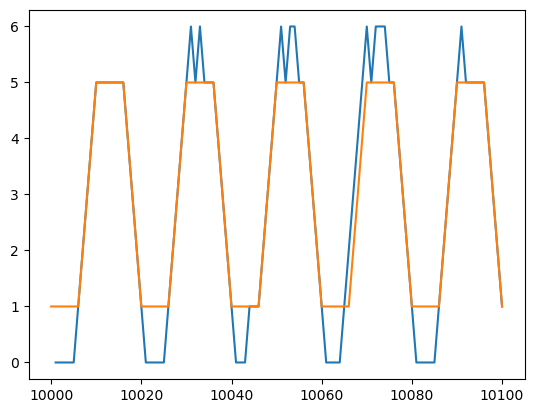

24000
(20000, 57) (20000, 1) (4000, 57) (4000, 1)
Epoch 01 | train MSE 0.041607 | val MSE 0.024318
Epoch 02 | train MSE 0.022484 | val MSE 0.019516
Epoch 03 | train MSE 0.018985 | val MSE 0.017228
Epoch 04 | train MSE 0.016656 | val MSE 0.013566
Epoch 05 | train MSE 0.010265 | val MSE 0.004829
Epoch 06 | train MSE 0.004616 | val MSE 0.002304
Epoch 07 | train MSE 0.002906 | val MSE 0.001053
Epoch 08 | train MSE 0.001996 | val MSE 0.000610
Epoch 09 | train MSE 0.001499 | val MSE 0.000497
Epoch 10 | train MSE 0.001260 | val MSE 0.000445
Epoch 11 | train MSE 0.001173 | val MSE 0.000340
Epoch 12 | train MSE 0.001031 | val MSE 0.000311
Epoch 13 | train MSE 0.000962 | val MSE 0.000254
Epoch 14 | train MSE 0.000886 | val MSE 0.000223
Epoch 15 | train MSE 0.000814 | val MSE 0.000199
Epoch 16 | train MSE 0.000770 | val MSE 0.000179
Epoch 17 | train MSE 0.000730 | val MSE 0.000170
Epoch 18 | train MSE 0.000697 | val MSE 0.000141
Epoch 19 | train MSE 0.000668 | val MSE 0.000139
Epoch 20 | train MS

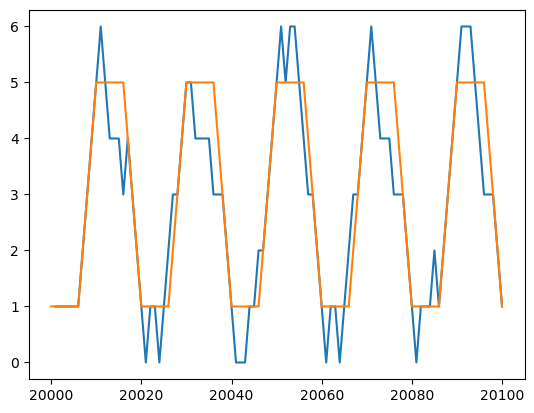

48000
(40000, 57) (40000, 1) (8000, 57) (8000, 1)
Epoch 01 | train MSE 0.033253 | val MSE 0.020355
Epoch 02 | train MSE 0.018391 | val MSE 0.015432
Epoch 03 | train MSE 0.008461 | val MSE 0.002591
Epoch 04 | train MSE 0.002468 | val MSE 0.000584
Epoch 05 | train MSE 0.001403 | val MSE 0.000384
Epoch 06 | train MSE 0.001102 | val MSE 0.000271
Epoch 07 | train MSE 0.000906 | val MSE 0.000219
Epoch 08 | train MSE 0.000816 | val MSE 0.000172
Epoch 09 | train MSE 0.000717 | val MSE 0.000147
Epoch 10 | train MSE 0.000657 | val MSE 0.000124
Epoch 11 | train MSE 0.000612 | val MSE 0.000097
Epoch 12 | train MSE 0.000564 | val MSE 0.000091
Epoch 13 | train MSE 0.000525 | val MSE 0.000084
Epoch 14 | train MSE 0.000504 | val MSE 0.000076
Epoch 15 | train MSE 0.000478 | val MSE 0.000066
Epoch 16 | train MSE 0.000449 | val MSE 0.000056
Epoch 17 | train MSE 0.000435 | val MSE 0.000054
Epoch 18 | train MSE 0.000413 | val MSE 0.000054
Epoch 19 | train MSE 0.000396 | val MSE 0.000050
Epoch 20 | train MS

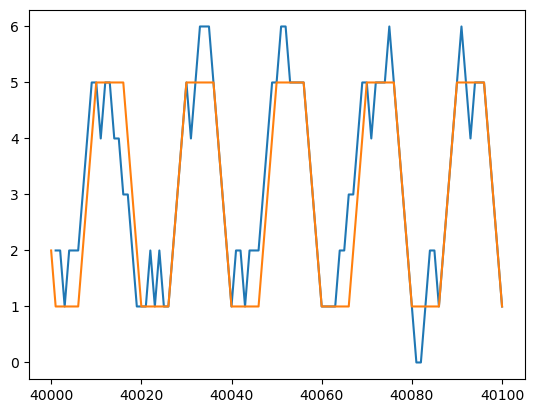

96000
(80000, 57) (80000, 1) (16000, 57) (16000, 1)
Epoch 01 | train MSE 0.023498 | val MSE 0.014633
Epoch 02 | train MSE 0.005020 | val MSE 0.000600
Epoch 03 | train MSE 0.001226 | val MSE 0.000275
Epoch 04 | train MSE 0.000868 | val MSE 0.000175
Epoch 05 | train MSE 0.000688 | val MSE 0.000134
Epoch 06 | train MSE 0.000578 | val MSE 0.000106
Epoch 07 | train MSE 0.000497 | val MSE 0.000076
Epoch 08 | train MSE 0.000445 | val MSE 0.000081
Epoch 09 | train MSE 0.000403 | val MSE 0.000057
Epoch 10 | train MSE 0.000369 | val MSE 0.000050
Epoch 11 | train MSE 0.000338 | val MSE 0.000048
Epoch 12 | train MSE 0.000311 | val MSE 0.000054
Epoch 13 | train MSE 0.000295 | val MSE 0.000040
Epoch 14 | train MSE 0.000280 | val MSE 0.000030
Epoch 15 | train MSE 0.000262 | val MSE 0.000035
Epoch 16 | train MSE 0.000245 | val MSE 0.000036
Epoch 17 | train MSE 0.000237 | val MSE 0.000023
Epoch 18 | train MSE 0.000222 | val MSE 0.000025
Epoch 19 | train MSE 0.000206 | val MSE 0.000022
Epoch 20 | train 

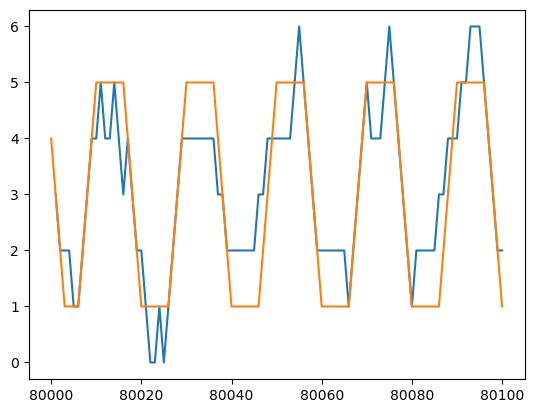

1200
(1000, 57) (1000, 1) (200, 57) (200, 1)
Epoch 01 | train MSE 0.127375 | val MSE 0.079875
Epoch 02 | train MSE 0.044231 | val MSE 0.032949
Epoch 03 | train MSE 0.029418 | val MSE 0.031946
Epoch 04 | train MSE 0.028532 | val MSE 0.031065
Epoch 05 | train MSE 0.028133 | val MSE 0.030296
Epoch 06 | train MSE 0.027004 | val MSE 0.029429
Epoch 07 | train MSE 0.025894 | val MSE 0.028662
Epoch 08 | train MSE 0.024725 | val MSE 0.027870
Epoch 09 | train MSE 0.023829 | val MSE 0.026986
Epoch 10 | train MSE 0.022874 | val MSE 0.026200
Epoch 11 | train MSE 0.021707 | val MSE 0.025448
Epoch 12 | train MSE 0.021208 | val MSE 0.024534
Epoch 13 | train MSE 0.020510 | val MSE 0.023641
Epoch 14 | train MSE 0.019247 | val MSE 0.023041
Epoch 15 | train MSE 0.019052 | val MSE 0.022583
Epoch 16 | train MSE 0.018276 | val MSE 0.021802
Epoch 17 | train MSE 0.017802 | val MSE 0.021228
Epoch 18 | train MSE 0.017323 | val MSE 0.020982
Epoch 19 | train MSE 0.015906 | val MSE 0.020603
Epoch 20 | train MSE 0.0

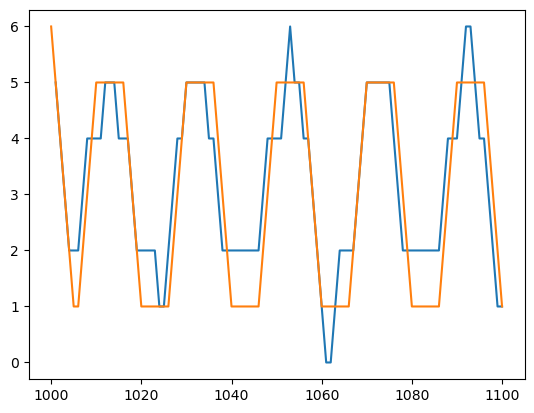

6000
(5000, 57) (5000, 1) (1000, 57) (1000, 1)
Epoch 01 | train MSE 0.052494 | val MSE 0.024078
Epoch 02 | train MSE 0.026143 | val MSE 0.021318
Epoch 03 | train MSE 0.023177 | val MSE 0.019494
Epoch 04 | train MSE 0.020330 | val MSE 0.018544
Epoch 05 | train MSE 0.019209 | val MSE 0.018052
Epoch 06 | train MSE 0.018715 | val MSE 0.017846
Epoch 07 | train MSE 0.017674 | val MSE 0.017665
Epoch 08 | train MSE 0.016539 | val MSE 0.016961
Epoch 09 | train MSE 0.015342 | val MSE 0.016202
Epoch 10 | train MSE 0.013818 | val MSE 0.014252
Epoch 11 | train MSE 0.011417 | val MSE 0.011676
Epoch 12 | train MSE 0.008817 | val MSE 0.008372
Epoch 13 | train MSE 0.006501 | val MSE 0.005558
Epoch 14 | train MSE 0.004938 | val MSE 0.004019
Epoch 15 | train MSE 0.004164 | val MSE 0.003334
Epoch 16 | train MSE 0.003538 | val MSE 0.002532
Epoch 17 | train MSE 0.002987 | val MSE 0.002130
Epoch 18 | train MSE 0.002675 | val MSE 0.001799
Epoch 19 | train MSE 0.002551 | val MSE 0.001631
Epoch 20 | train MSE 0

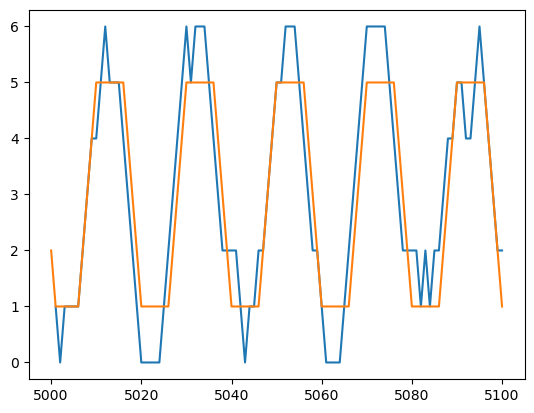

12000
(10000, 57) (10000, 1) (2000, 57) (2000, 1)
Epoch 01 | train MSE 0.043360 | val MSE 0.024816
Epoch 02 | train MSE 0.023632 | val MSE 0.020222
Epoch 03 | train MSE 0.019817 | val MSE 0.018453
Epoch 04 | train MSE 0.018134 | val MSE 0.016946
Epoch 05 | train MSE 0.015876 | val MSE 0.013013
Epoch 06 | train MSE 0.009473 | val MSE 0.004353
Epoch 07 | train MSE 0.004409 | val MSE 0.001991
Epoch 08 | train MSE 0.002773 | val MSE 0.001056
Epoch 09 | train MSE 0.002017 | val MSE 0.000813
Epoch 10 | train MSE 0.001632 | val MSE 0.000657
Epoch 11 | train MSE 0.001497 | val MSE 0.000563
Epoch 12 | train MSE 0.001362 | val MSE 0.000501
Epoch 13 | train MSE 0.001201 | val MSE 0.000445
Epoch 14 | train MSE 0.001072 | val MSE 0.000394
Epoch 15 | train MSE 0.001027 | val MSE 0.000342
Epoch 16 | train MSE 0.000987 | val MSE 0.000333
Epoch 17 | train MSE 0.000910 | val MSE 0.000302
Epoch 18 | train MSE 0.000882 | val MSE 0.000276
Epoch 19 | train MSE 0.000856 | val MSE 0.000241
Epoch 20 | train MS

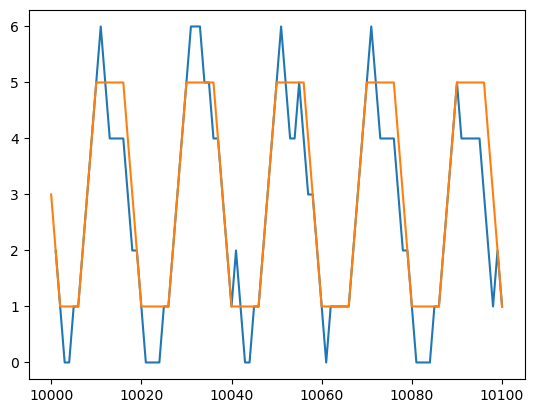

24000
(20000, 57) (20000, 1) (4000, 57) (4000, 1)
Epoch 01 | train MSE 0.043214 | val MSE 0.023491
Epoch 02 | train MSE 0.022555 | val MSE 0.019664
Epoch 03 | train MSE 0.019305 | val MSE 0.018058
Epoch 04 | train MSE 0.017394 | val MSE 0.015914
Epoch 05 | train MSE 0.013295 | val MSE 0.008587
Epoch 06 | train MSE 0.006168 | val MSE 0.002376
Epoch 07 | train MSE 0.003111 | val MSE 0.001042
Epoch 08 | train MSE 0.002023 | val MSE 0.000721
Epoch 09 | train MSE 0.001676 | val MSE 0.000594
Epoch 10 | train MSE 0.001346 | val MSE 0.000471
Epoch 11 | train MSE 0.001271 | val MSE 0.000415
Epoch 12 | train MSE 0.001114 | val MSE 0.000366
Epoch 13 | train MSE 0.001004 | val MSE 0.000325
Epoch 14 | train MSE 0.000943 | val MSE 0.000274
Epoch 15 | train MSE 0.000868 | val MSE 0.000238
Epoch 16 | train MSE 0.000809 | val MSE 0.000213
Epoch 17 | train MSE 0.000765 | val MSE 0.000184
Epoch 18 | train MSE 0.000705 | val MSE 0.000177
Epoch 19 | train MSE 0.000689 | val MSE 0.000157
Epoch 20 | train MS

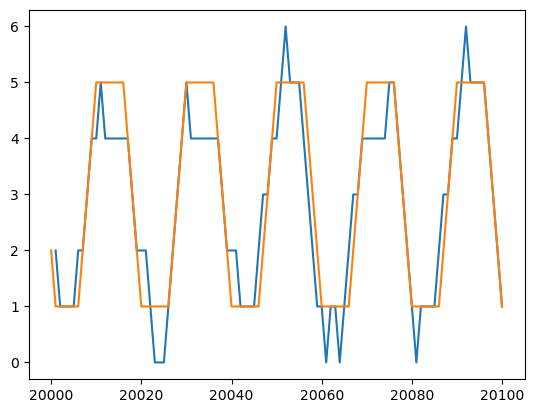

48000
(40000, 57) (40000, 1) (8000, 57) (8000, 1)
Epoch 01 | train MSE 0.032743 | val MSE 0.019762
Epoch 02 | train MSE 0.018363 | val MSE 0.015363
Epoch 03 | train MSE 0.008829 | val MSE 0.002275
Epoch 04 | train MSE 0.002328 | val MSE 0.000603
Epoch 05 | train MSE 0.001419 | val MSE 0.000387
Epoch 06 | train MSE 0.001105 | val MSE 0.000297
Epoch 07 | train MSE 0.000924 | val MSE 0.000218
Epoch 08 | train MSE 0.000800 | val MSE 0.000174
Epoch 09 | train MSE 0.000716 | val MSE 0.000149
Epoch 10 | train MSE 0.000640 | val MSE 0.000112
Epoch 11 | train MSE 0.000595 | val MSE 0.000097
Epoch 12 | train MSE 0.000547 | val MSE 0.000084
Epoch 13 | train MSE 0.000519 | val MSE 0.000086
Epoch 14 | train MSE 0.000494 | val MSE 0.000080
Epoch 15 | train MSE 0.000456 | val MSE 0.000066
Epoch 16 | train MSE 0.000435 | val MSE 0.000063
Epoch 17 | train MSE 0.000424 | val MSE 0.000053
Epoch 18 | train MSE 0.000403 | val MSE 0.000045
Epoch 19 | train MSE 0.000376 | val MSE 0.000052
Epoch 20 | train MS

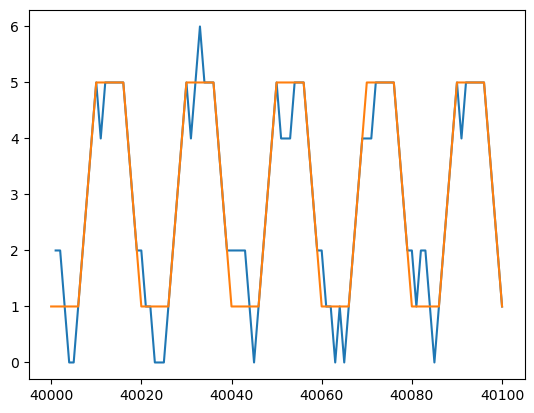

96000
(80000, 57) (80000, 1) (16000, 57) (16000, 1)
Epoch 01 | train MSE 0.025009 | val MSE 0.014355
Epoch 02 | train MSE 0.004931 | val MSE 0.000552
Epoch 03 | train MSE 0.001207 | val MSE 0.000287
Epoch 04 | train MSE 0.000859 | val MSE 0.000165
Epoch 05 | train MSE 0.000690 | val MSE 0.000113
Epoch 06 | train MSE 0.000586 | val MSE 0.000093
Epoch 07 | train MSE 0.000512 | val MSE 0.000070
Epoch 08 | train MSE 0.000451 | val MSE 0.000062
Epoch 09 | train MSE 0.000412 | val MSE 0.000052
Epoch 10 | train MSE 0.000378 | val MSE 0.000047
Epoch 11 | train MSE 0.000351 | val MSE 0.000048
Epoch 12 | train MSE 0.000327 | val MSE 0.000033
Epoch 13 | train MSE 0.000310 | val MSE 0.000033
Epoch 14 | train MSE 0.000293 | val MSE 0.000039
Epoch 15 | train MSE 0.000273 | val MSE 0.000027
Epoch 16 | train MSE 0.000261 | val MSE 0.000035
Epoch 17 | train MSE 0.000252 | val MSE 0.000026
Epoch 18 | train MSE 0.000233 | val MSE 0.000026
Epoch 19 | train MSE 0.000226 | val MSE 0.000028
Epoch 20 | train 

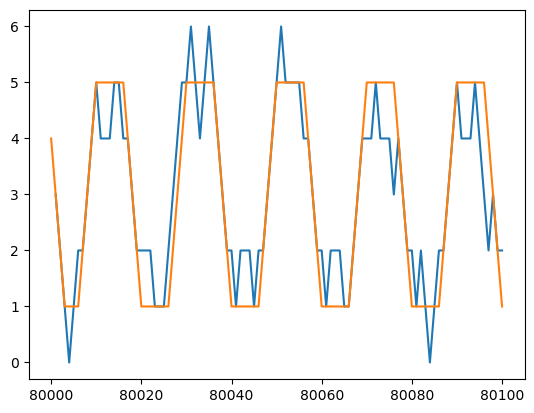

1200
(1000, 57) (1000, 1) (200, 57) (200, 1)
Epoch 01 | train MSE 0.127105 | val MSE 0.082078
Epoch 02 | train MSE 0.050854 | val MSE 0.033628
Epoch 03 | train MSE 0.028444 | val MSE 0.033513
Epoch 04 | train MSE 0.027568 | val MSE 0.032282
Epoch 05 | train MSE 0.026918 | val MSE 0.031458
Epoch 06 | train MSE 0.026117 | val MSE 0.030691
Epoch 07 | train MSE 0.026178 | val MSE 0.029739
Epoch 08 | train MSE 0.024586 | val MSE 0.028998
Epoch 09 | train MSE 0.024948 | val MSE 0.028218
Epoch 10 | train MSE 0.024066 | val MSE 0.027107
Epoch 11 | train MSE 0.022097 | val MSE 0.026372
Epoch 12 | train MSE 0.022232 | val MSE 0.025481
Epoch 13 | train MSE 0.020747 | val MSE 0.024517
Epoch 14 | train MSE 0.020354 | val MSE 0.024128
Epoch 15 | train MSE 0.019310 | val MSE 0.023231
Epoch 16 | train MSE 0.019366 | val MSE 0.022423
Epoch 17 | train MSE 0.019073 | val MSE 0.022104
Epoch 18 | train MSE 0.018810 | val MSE 0.021822
Epoch 19 | train MSE 0.017245 | val MSE 0.021459
Epoch 20 | train MSE 0.0

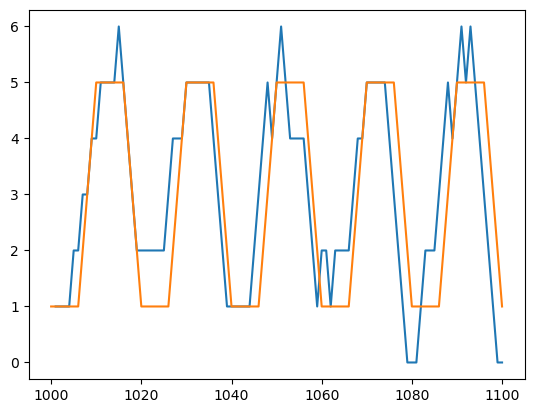

6000
(5000, 57) (5000, 1) (1000, 57) (1000, 1)
Epoch 01 | train MSE 0.045474 | val MSE 0.024221
Epoch 02 | train MSE 0.024328 | val MSE 0.021126
Epoch 03 | train MSE 0.021634 | val MSE 0.018858
Epoch 04 | train MSE 0.019377 | val MSE 0.017799
Epoch 05 | train MSE 0.017985 | val MSE 0.017153
Epoch 06 | train MSE 0.017166 | val MSE 0.016574
Epoch 07 | train MSE 0.015906 | val MSE 0.015930
Epoch 08 | train MSE 0.014179 | val MSE 0.014777
Epoch 09 | train MSE 0.013100 | val MSE 0.013159
Epoch 10 | train MSE 0.010522 | val MSE 0.010896
Epoch 11 | train MSE 0.008512 | val MSE 0.008676
Epoch 12 | train MSE 0.006572 | val MSE 0.006322
Epoch 13 | train MSE 0.005207 | val MSE 0.005154
Epoch 14 | train MSE 0.004416 | val MSE 0.004143
Epoch 15 | train MSE 0.003929 | val MSE 0.003157
Epoch 16 | train MSE 0.003340 | val MSE 0.002473
Epoch 17 | train MSE 0.003075 | val MSE 0.002130
Epoch 18 | train MSE 0.002741 | val MSE 0.002155
Epoch 19 | train MSE 0.002620 | val MSE 0.001758
Epoch 20 | train MSE 0

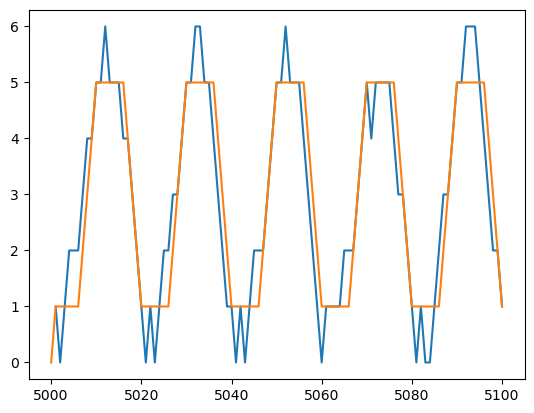

12000
(10000, 57) (10000, 1) (2000, 57) (2000, 1)
Epoch 01 | train MSE 0.040449 | val MSE 0.024976
Epoch 02 | train MSE 0.021872 | val MSE 0.021128
Epoch 03 | train MSE 0.019297 | val MSE 0.019308
Epoch 04 | train MSE 0.017245 | val MSE 0.017783
Epoch 05 | train MSE 0.014771 | val MSE 0.013788
Epoch 06 | train MSE 0.008578 | val MSE 0.004589
Epoch 07 | train MSE 0.003870 | val MSE 0.002057
Epoch 08 | train MSE 0.002577 | val MSE 0.001148
Epoch 09 | train MSE 0.001886 | val MSE 0.000777
Epoch 10 | train MSE 0.001545 | val MSE 0.000626
Epoch 11 | train MSE 0.001346 | val MSE 0.000528
Epoch 12 | train MSE 0.001188 | val MSE 0.000469
Epoch 13 | train MSE 0.001099 | val MSE 0.000422
Epoch 14 | train MSE 0.001014 | val MSE 0.000379
Epoch 15 | train MSE 0.000930 | val MSE 0.000339
Epoch 16 | train MSE 0.000915 | val MSE 0.000326
Epoch 17 | train MSE 0.000880 | val MSE 0.000327
Epoch 18 | train MSE 0.000860 | val MSE 0.000267
Epoch 19 | train MSE 0.000754 | val MSE 0.000246
Epoch 20 | train MS

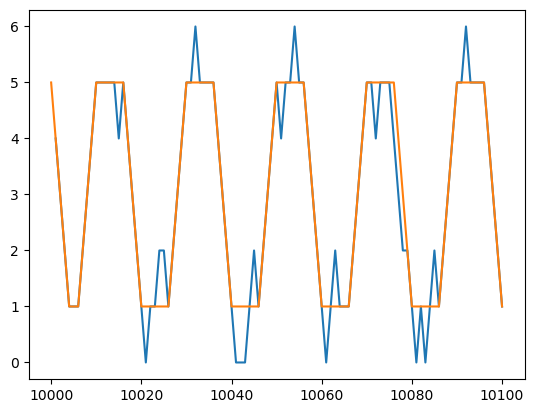

24000
(20000, 57) (20000, 1) (4000, 57) (4000, 1)
Epoch 01 | train MSE 0.041118 | val MSE 0.025240
Epoch 02 | train MSE 0.022857 | val MSE 0.020100
Epoch 03 | train MSE 0.019086 | val MSE 0.017892
Epoch 04 | train MSE 0.016631 | val MSE 0.014373
Epoch 05 | train MSE 0.010919 | val MSE 0.005452
Epoch 06 | train MSE 0.004675 | val MSE 0.001963
Epoch 07 | train MSE 0.002710 | val MSE 0.000937
Epoch 08 | train MSE 0.001890 | val MSE 0.000644
Epoch 09 | train MSE 0.001509 | val MSE 0.000537
Epoch 10 | train MSE 0.001337 | val MSE 0.000442
Epoch 11 | train MSE 0.001168 | val MSE 0.000383
Epoch 12 | train MSE 0.001067 | val MSE 0.000348
Epoch 13 | train MSE 0.001008 | val MSE 0.000305
Epoch 14 | train MSE 0.000949 | val MSE 0.000269
Epoch 15 | train MSE 0.000866 | val MSE 0.000235
Epoch 16 | train MSE 0.000822 | val MSE 0.000211
Epoch 17 | train MSE 0.000779 | val MSE 0.000194
Epoch 18 | train MSE 0.000730 | val MSE 0.000187
Epoch 19 | train MSE 0.000721 | val MSE 0.000177
Epoch 20 | train MS

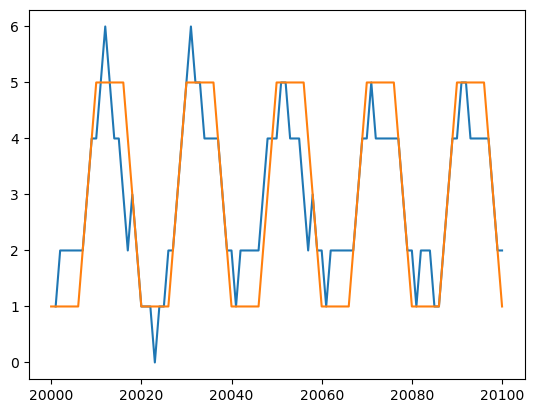

48000
(40000, 57) (40000, 1) (8000, 57) (8000, 1)
Epoch 01 | train MSE 0.031006 | val MSE 0.019977
Epoch 02 | train MSE 0.017870 | val MSE 0.013702
Epoch 03 | train MSE 0.006627 | val MSE 0.001313
Epoch 04 | train MSE 0.001877 | val MSE 0.000521
Epoch 05 | train MSE 0.001272 | val MSE 0.000357
Epoch 06 | train MSE 0.000991 | val MSE 0.000249
Epoch 07 | train MSE 0.000852 | val MSE 0.000188
Epoch 08 | train MSE 0.000756 | val MSE 0.000150
Epoch 09 | train MSE 0.000672 | val MSE 0.000133
Epoch 10 | train MSE 0.000616 | val MSE 0.000117
Epoch 11 | train MSE 0.000569 | val MSE 0.000096
Epoch 12 | train MSE 0.000520 | val MSE 0.000086
Epoch 13 | train MSE 0.000494 | val MSE 0.000074
Epoch 14 | train MSE 0.000468 | val MSE 0.000067
Epoch 15 | train MSE 0.000435 | val MSE 0.000070
Epoch 16 | train MSE 0.000420 | val MSE 0.000061
Epoch 17 | train MSE 0.000403 | val MSE 0.000059
Epoch 18 | train MSE 0.000383 | val MSE 0.000055
Epoch 19 | train MSE 0.000368 | val MSE 0.000048
Epoch 20 | train MS

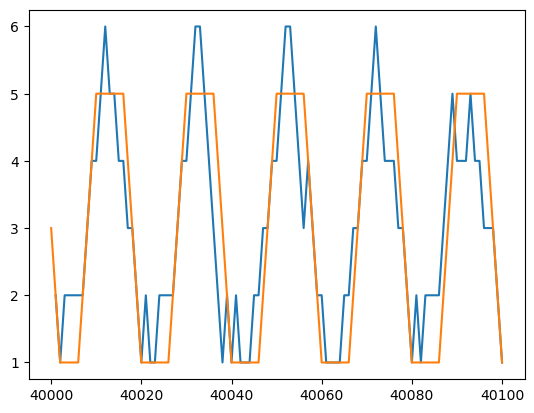

96000
(80000, 57) (80000, 1) (16000, 57) (16000, 1)
Epoch 01 | train MSE 0.025534 | val MSE 0.013466
Epoch 02 | train MSE 0.004727 | val MSE 0.000574
Epoch 03 | train MSE 0.001275 | val MSE 0.000290
Epoch 04 | train MSE 0.000892 | val MSE 0.000172
Epoch 05 | train MSE 0.000706 | val MSE 0.000118
Epoch 06 | train MSE 0.000595 | val MSE 0.000111
Epoch 07 | train MSE 0.000527 | val MSE 0.000083
Epoch 08 | train MSE 0.000472 | val MSE 0.000089
Epoch 09 | train MSE 0.000432 | val MSE 0.000055
Epoch 10 | train MSE 0.000393 | val MSE 0.000048
Epoch 11 | train MSE 0.000370 | val MSE 0.000049
Epoch 12 | train MSE 0.000343 | val MSE 0.000045
Epoch 13 | train MSE 0.000327 | val MSE 0.000036
Epoch 14 | train MSE 0.000308 | val MSE 0.000035
Epoch 15 | train MSE 0.000288 | val MSE 0.000032
Epoch 16 | train MSE 0.000277 | val MSE 0.000034
Epoch 17 | train MSE 0.000262 | val MSE 0.000023
Epoch 18 | train MSE 0.000247 | val MSE 0.000022
Epoch 19 | train MSE 0.000236 | val MSE 0.000021
Epoch 20 | train 

In [ ]:
DELTA_t = 10
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T_initial in Ts:
        # n_seq = int(T/(DELTA_t+1))
        T_val = int(T_initial*0.2)
        T= T_val + T_initial
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T_initial-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:]
        
        X_train = STATES_arr[:T_initial,:]
        Y_train = np.array(REWARDS_arr[:T_initial]).reshape(-1,1)/ 10

        X_val = STATES_arr[T_initial:T,:]
        Y_val = np.array(REWARDS_arr[T_initial:T]).reshape(-1,1)/ 10
        print(X_train.shape,Y_train.shape,X_val.shape,Y_val.shape)
        
        epochs = 500
        weight_decay = 1e-6
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            epochs = 500
            # hidden_layers = (192,128)
        elif T_initial == 10000:
            learning_rate = 3e-4
            batch_size_train = 128
            # hidden_layers = (512,256)
        elif T_initial == 20000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            learning_rate = 3e-4
            batch_size_train = 256
            hidden_layers = (512,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_initial+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_initial+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*10
                prewards_pred[:,i] = pred_val
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T_initial+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T_initial+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T_initial, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T_initial+1,T_initial+101),future_states[1:])
        plt.plot(np.arange(T_initial,T_initial+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/NN_Yuxin/NN_SameStructure_optimal_oh_w_time1000_80000_w_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.191110 | val MSE 0.130007
Epoch 02 | train MSE 0.108602 | val MSE 0.038478
Epoch 03 | train MSE 0.070409 | val MSE 0.017948
Epoch 04 | train MSE 0.064069 | val MSE 0.016283
Epoch 05 | train MSE 0.062874 | val MSE 0.015720
Epoch 06 | train MSE 0.061215 | val MSE 0.016169
Epoch 07 | train MSE 0.060322 | val MSE 0.016523
Epoch 08 | train MSE 0.058475 | val MSE 0.016794
Epoch 09 | train MSE 0.057203 | val MSE 0.016243
Epoch 10 | train MSE 0.054891 | val MSE 0.017682
Epoch 11 | train MSE 0.064835 | val MSE 0.017365
Epoch 12 | train MSE 0.050188 | val MSE 0.018051
Epoch 13 | train MSE 0.048391 | val MSE 0.018025
Epoch 14 | train MSE 0.046032 | val MSE 0.017944
Epoch 15 | train MSE 0.042336 | val MSE 0.018593
Epoch 16 | train MSE 0.039257 | val MSE 0.019013
Epoch 17 | train MSE 0.040583 | val MSE 0.020344
Epoch 18 | train MSE 0.035941 | val MSE 0.019719
Epoch 19 | train MSE 0.032561 | val MSE 0.020053
Epoch 20 | train MSE 0.03

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/2784702331.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prewards_pred[:,i] = pred_val


2.4051798883886897


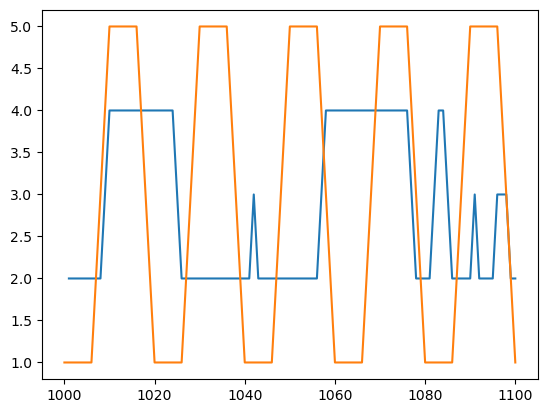

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.098159 | val MSE 0.041510
Epoch 02 | train MSE 0.063535 | val MSE 0.041176
Epoch 03 | train MSE 0.061721 | val MSE 0.040038
Epoch 04 | train MSE 0.059220 | val MSE 0.039837
Epoch 05 | train MSE 0.056624 | val MSE 0.040460
Epoch 06 | train MSE 0.054312 | val MSE 0.040758
Epoch 07 | train MSE 0.051759 | val MSE 0.041506
Epoch 08 | train MSE 0.048417 | val MSE 0.041427
Epoch 09 | train MSE 0.044593 | val MSE 0.042520
Epoch 10 | train MSE 0.040870 | val MSE 0.043082
Epoch 11 | train MSE 0.036649 | val MSE 0.043558
Epoch 12 | train MSE 0.034356 | val MSE 0.044283
Epoch 13 | train MSE 0.032099 | val MSE 0.046159
Epoch 14 | train MSE 0.029428 | val MSE 0.045672
Epoch 15 | train MSE 0.027321 | val MSE 0.046680
Epoch 16 | train MSE 0.025625 | val MSE 0.047176
Epoch 17 | train MSE 0.024080 | val MSE 0.045858
Epoch 18 | train MSE 0.023629 | val MSE 0.044946
Epoch 19 | train MSE 0.022426 | val MSE 0.047304
Epoch 20 | train MSE 0.

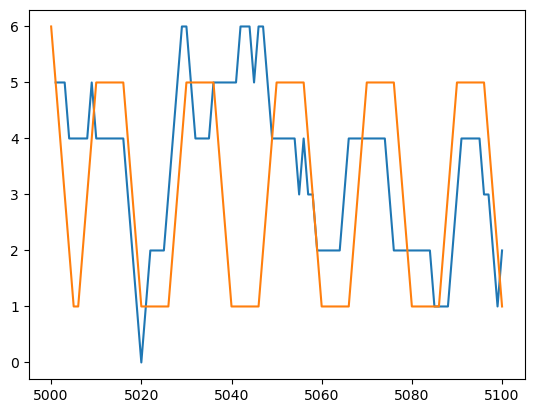

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.087789 | val MSE 0.074794
Epoch 02 | train MSE 0.077074 | val MSE 0.074794
Epoch 03 | train MSE 0.076690 | val MSE 0.074794
Epoch 04 | train MSE 0.077222 | val MSE 0.074794
Epoch 05 | train MSE 0.076616 | val MSE 0.074794
Epoch 06 | train MSE 0.077622 | val MSE 0.074794
Epoch 07 | train MSE 0.076669 | val MSE 0.074794
Epoch 08 | train MSE 0.076618 | val MSE 0.074794
Epoch 09 | train MSE 0.077318 | val MSE 0.074794
Epoch 10 | train MSE 0.076991 | val MSE 0.074794
Epoch 11 | train MSE 0.076961 | val MSE 0.074794
Epoch 12 | train MSE 0.077581 | val MSE 0.074794
Epoch 13 | train MSE 0.076774 | val MSE 0.074794
Epoch 14 | train MSE 0.077131 | val MSE 0.074794
Epoch 15 | train MSE 0.077050 | val MSE 0.074794
Epoch 16 | train MSE 0.077611 | val MSE 0.074794
Epoch 17 | train MSE 0.076152 | val MSE 0.074794
Epoch 18 | train MSE 0.077762 | val MSE 0.074794
Epoch 19 | train MSE 0.077184 | val MSE 0.074794
Epoch 20 | train MSE 0

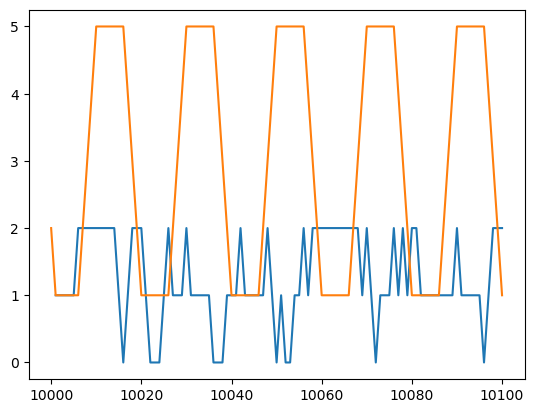

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.080808 | val MSE 0.070709
Epoch 02 | train MSE 0.075618 | val MSE 0.070709
Epoch 03 | train MSE 0.076414 | val MSE 0.070709
Epoch 04 | train MSE 0.075290 | val MSE 0.070709
Epoch 05 | train MSE 0.074407 | val MSE 0.070709
Epoch 06 | train MSE 0.075778 | val MSE 0.070709
Epoch 07 | train MSE 0.075722 | val MSE 0.070709
Epoch 08 | train MSE 0.074696 | val MSE 0.070709
Epoch 09 | train MSE 0.073889 | val MSE 0.070709
Epoch 10 | train MSE 0.074213 | val MSE 0.070709
Epoch 11 | train MSE 0.075058 | val MSE 0.070709
Epoch 12 | train MSE 0.074667 | val MSE 0.070709
Epoch 13 | train MSE 0.074660 | val MSE 0.070709
Epoch 14 | train MSE 0.074688 | val MSE 0.070709
Epoch 15 | train MSE 0.073973 | val MSE 0.070709
Epoch 16 | train MSE 0.075891 | val MSE 0.070709
Epoch 17 | train MSE 0.076254 | val MSE 0.070709
Epoch 18 | train MSE 0.078288 | val MSE 0.070709
Epoch 19 | train MSE 0.075309 | val MSE 0.070709
Epoch 20 | train MSE

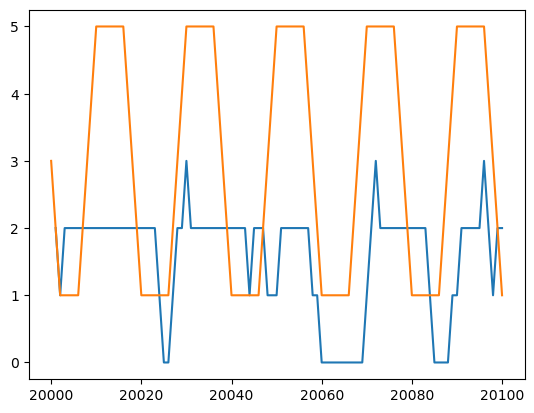

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077707 | val MSE 0.084512
Epoch 02 | train MSE 0.074501 | val MSE 0.084512
Epoch 03 | train MSE 0.074459 | val MSE 0.084512
Epoch 04 | train MSE 0.075033 | val MSE 0.084512
Epoch 05 | train MSE 0.074877 | val MSE 0.084512
Epoch 06 | train MSE 0.074443 | val MSE 0.084512
Epoch 07 | train MSE 0.074964 | val MSE 0.084512
Epoch 08 | train MSE 0.074794 | val MSE 0.084512
Epoch 09 | train MSE 0.074947 | val MSE 0.084512
Epoch 10 | train MSE 0.074713 | val MSE 0.084512
Epoch 11 | train MSE 0.074591 | val MSE 0.084512
Epoch 12 | train MSE 0.075224 | val MSE 0.084512
Epoch 13 | train MSE 0.074677 | val MSE 0.084512
Epoch 14 | train MSE 0.075269 | val MSE 0.084512
Epoch 15 | train MSE 0.074436 | val MSE 0.084512
Epoch 16 | train MSE 0.074827 | val MSE 0.084512
Epoch 17 | train MSE 0.075039 | val MSE 0.084512
Epoch 18 | train MSE 0.074548 | val MSE 0.084512
Epoch 19 | train MSE 0.074803 | val MSE 0.084512
Epoch 20 | train MSE

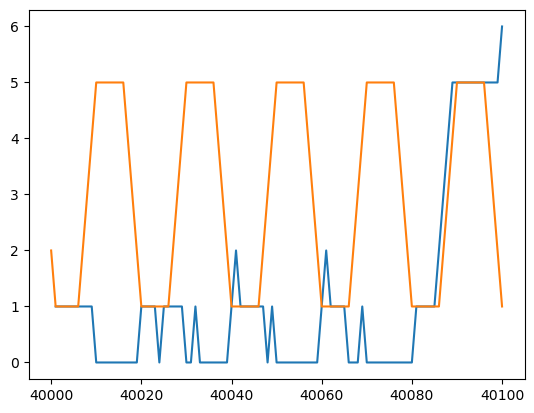

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078226 | val MSE 0.073697
Epoch 02 | train MSE 0.076867 | val MSE 0.073697
Epoch 03 | train MSE 0.076915 | val MSE 0.073697
Epoch 04 | train MSE 0.076812 | val MSE 0.073697
Epoch 05 | train MSE 0.076789 | val MSE 0.073697
Epoch 06 | train MSE 0.076794 | val MSE 0.073697
Epoch 07 | train MSE 0.076941 | val MSE 0.073697
Epoch 08 | train MSE 0.076873 | val MSE 0.073697
Epoch 09 | train MSE 0.076835 | val MSE 0.073697
Epoch 10 | train MSE 0.076789 | val MSE 0.073697
Epoch 11 | train MSE 0.076778 | val MSE 0.073697
Epoch 12 | train MSE 0.076810 | val MSE 0.073697
Epoch 13 | train MSE 0.076748 | val MSE 0.073697
Epoch 14 | train MSE 0.076889 | val MSE 0.073697
Epoch 15 | train MSE 0.076834 | val MSE 0.073697
Epoch 16 | train MSE 0.076758 | val MSE 0.073697
Epoch 17 | train MSE 0.076837 | val MSE 0.073697
Epoch 18 | train MSE 0.076834 | val MSE 0.073697
Epoch 19 | train MSE 0.076763 | val MSE 0.073697
Epoch 20 | train MSE

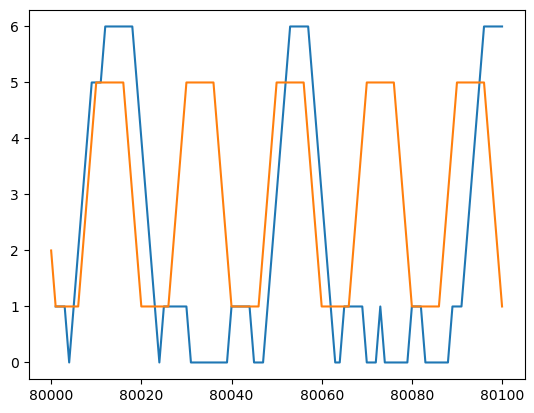

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.186367 | val MSE 0.113539
Epoch 02 | train MSE 0.091787 | val MSE 0.026374
Epoch 03 | train MSE 0.066304 | val MSE 0.016559
Epoch 04 | train MSE 0.064392 | val MSE 0.015984
Epoch 05 | train MSE 0.063058 | val MSE 0.017002
Epoch 06 | train MSE 0.061817 | val MSE 0.017179
Epoch 07 | train MSE 0.061299 | val MSE 0.017432
Epoch 08 | train MSE 0.059139 | val MSE 0.017837
Epoch 09 | train MSE 0.070602 | val MSE 0.018221
Epoch 10 | train MSE 0.060335 | val MSE 0.019696
Epoch 11 | train MSE 0.052806 | val MSE 0.019348
Epoch 12 | train MSE 0.051447 | val MSE 0.019560
Epoch 13 | train MSE 0.048099 | val MSE 0.021303
Epoch 14 | train MSE 0.045787 | val MSE 0.020823
Epoch 15 | train MSE 0.043169 | val MSE 0.021949
Epoch 16 | train MSE 0.041569 | val MSE 0.023123
Epoch 17 | train MSE 0.038858 | val MSE 0.023819
Epoch 18 | train MSE 0.035959 | val MSE 0.024117
Epoch 19 | train MSE 0.033484 | val MSE 0.024829
Epoch 20 | train MSE 0.03

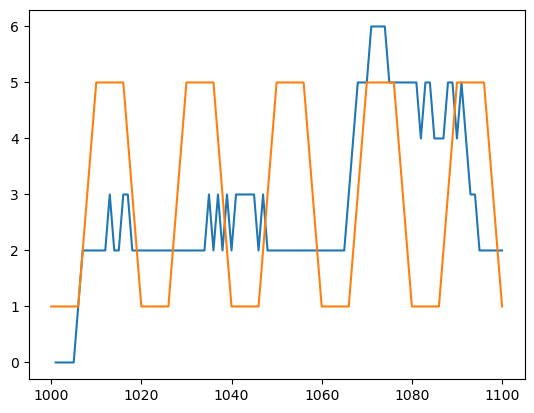

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.102194 | val MSE 0.040663
Epoch 02 | train MSE 0.064113 | val MSE 0.040121
Epoch 03 | train MSE 0.061945 | val MSE 0.039293
Epoch 04 | train MSE 0.059942 | val MSE 0.039127
Epoch 05 | train MSE 0.056980 | val MSE 0.040022
Epoch 06 | train MSE 0.055091 | val MSE 0.039514
Epoch 07 | train MSE 0.052051 | val MSE 0.040314
Epoch 08 | train MSE 0.048974 | val MSE 0.040437
Epoch 09 | train MSE 0.046203 | val MSE 0.042116
Epoch 10 | train MSE 0.042697 | val MSE 0.042651
Epoch 11 | train MSE 0.039440 | val MSE 0.044834
Epoch 12 | train MSE 0.036106 | val MSE 0.041063
Epoch 13 | train MSE 0.033058 | val MSE 0.045302
Epoch 14 | train MSE 0.031174 | val MSE 0.043214
Epoch 15 | train MSE 0.029443 | val MSE 0.045418
Epoch 16 | train MSE 0.026392 | val MSE 0.042820
Epoch 17 | train MSE 0.025762 | val MSE 0.042061
Epoch 18 | train MSE 0.023282 | val MSE 0.043525
Epoch 19 | train MSE 0.022911 | val MSE 0.045955
Epoch 20 | train MSE 0.

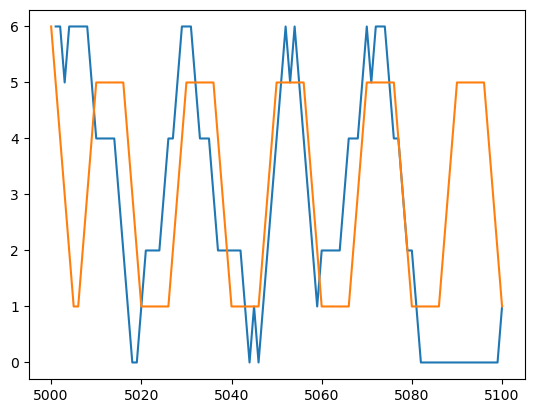

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.087439 | val MSE 0.074794
Epoch 02 | train MSE 0.076997 | val MSE 0.074794
Epoch 03 | train MSE 0.077224 | val MSE 0.074794
Epoch 04 | train MSE 0.077776 | val MSE 0.074794
Epoch 05 | train MSE 0.077111 | val MSE 0.074794
Epoch 06 | train MSE 0.077275 | val MSE 0.074794
Epoch 07 | train MSE 0.076235 | val MSE 0.074794
Epoch 08 | train MSE 0.077461 | val MSE 0.074794
Epoch 09 | train MSE 0.077528 | val MSE 0.074794
Epoch 10 | train MSE 0.077035 | val MSE 0.074794
Epoch 11 | train MSE 0.076521 | val MSE 0.074794
Epoch 12 | train MSE 0.076862 | val MSE 0.074794
Epoch 13 | train MSE 0.076423 | val MSE 0.074794
Epoch 14 | train MSE 0.076814 | val MSE 0.074794
Epoch 15 | train MSE 0.076750 | val MSE 0.074794
Epoch 16 | train MSE 0.076525 | val MSE 0.074794
Epoch 17 | train MSE 0.076351 | val MSE 0.074794
Epoch 18 | train MSE 0.077723 | val MSE 0.074794
Epoch 19 | train MSE 0.077085 | val MSE 0.074794
Epoch 20 | train MSE 0

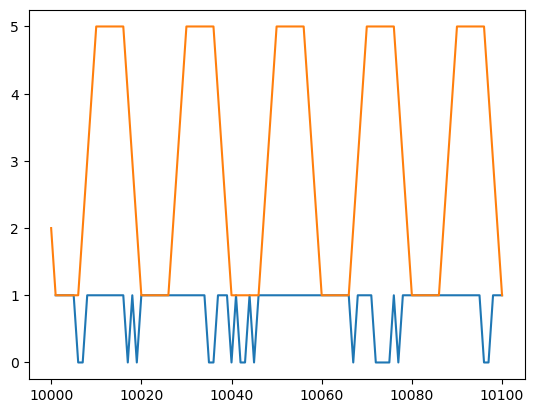

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.081046 | val MSE 0.070709
Epoch 02 | train MSE 0.075772 | val MSE 0.070709
Epoch 03 | train MSE 0.074994 | val MSE 0.070709
Epoch 04 | train MSE 0.075168 | val MSE 0.070709
Epoch 05 | train MSE 0.075840 | val MSE 0.070709
Epoch 06 | train MSE 0.074218 | val MSE 0.070709
Epoch 07 | train MSE 0.074665 | val MSE 0.070709
Epoch 08 | train MSE 0.076510 | val MSE 0.070709
Epoch 09 | train MSE 0.075118 | val MSE 0.070709
Epoch 10 | train MSE 0.075944 | val MSE 0.070709
Epoch 11 | train MSE 0.075538 | val MSE 0.070709
Epoch 12 | train MSE 0.077173 | val MSE 0.070709
Epoch 13 | train MSE 0.075408 | val MSE 0.070709
Epoch 14 | train MSE 0.075469 | val MSE 0.070709
Epoch 15 | train MSE 0.075167 | val MSE 0.070709
Epoch 16 | train MSE 0.075218 | val MSE 0.070709
Epoch 17 | train MSE 0.074961 | val MSE 0.070709
Epoch 18 | train MSE 0.077716 | val MSE 0.070709
Epoch 19 | train MSE 0.074232 | val MSE 0.070709
Epoch 20 | train MSE

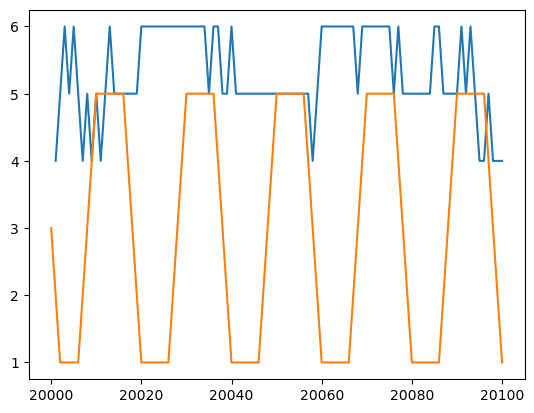

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.078110 | val MSE 0.084512
Epoch 02 | train MSE 0.074476 | val MSE 0.084512
Epoch 03 | train MSE 0.074519 | val MSE 0.084512
Epoch 04 | train MSE 0.074813 | val MSE 0.084512
Epoch 05 | train MSE 0.074574 | val MSE 0.084512
Epoch 06 | train MSE 0.075453 | val MSE 0.084512
Epoch 07 | train MSE 0.074868 | val MSE 0.084512
Epoch 08 | train MSE 0.074577 | val MSE 0.084512
Epoch 09 | train MSE 0.074605 | val MSE 0.084512
Epoch 10 | train MSE 0.074467 | val MSE 0.084512
Epoch 11 | train MSE 0.075141 | val MSE 0.084512
Epoch 12 | train MSE 0.075061 | val MSE 0.084512
Epoch 13 | train MSE 0.074920 | val MSE 0.084512
Epoch 14 | train MSE 0.074545 | val MSE 0.084512
Epoch 15 | train MSE 0.074548 | val MSE 0.084512
Epoch 16 | train MSE 0.074674 | val MSE 0.084512
Epoch 17 | train MSE 0.074866 | val MSE 0.084512
Epoch 18 | train MSE 0.074686 | val MSE 0.084512
Epoch 19 | train MSE 0.074639 | val MSE 0.084512
Epoch 20 | train MSE

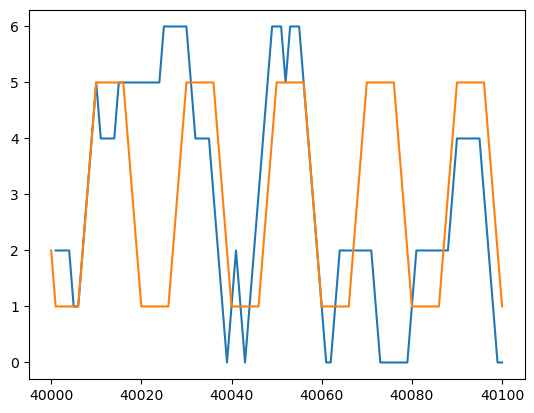

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078073 | val MSE 0.073697
Epoch 02 | train MSE 0.076901 | val MSE 0.073697
Epoch 03 | train MSE 0.076870 | val MSE 0.073697
Epoch 04 | train MSE 0.076789 | val MSE 0.073697
Epoch 05 | train MSE 0.076805 | val MSE 0.073697
Epoch 06 | train MSE 0.076802 | val MSE 0.073697
Epoch 07 | train MSE 0.076891 | val MSE 0.073697
Epoch 08 | train MSE 0.076772 | val MSE 0.073697
Epoch 09 | train MSE 0.076756 | val MSE 0.073697
Epoch 10 | train MSE 0.076858 | val MSE 0.073697
Epoch 11 | train MSE 0.076842 | val MSE 0.073697
Epoch 12 | train MSE 0.076905 | val MSE 0.073697
Epoch 13 | train MSE 0.076931 | val MSE 0.073697
Epoch 14 | train MSE 0.076849 | val MSE 0.073697
Epoch 15 | train MSE 0.076807 | val MSE 0.073697
Epoch 16 | train MSE 0.076802 | val MSE 0.073697
Epoch 17 | train MSE 0.076781 | val MSE 0.073697
Epoch 18 | train MSE 0.076835 | val MSE 0.073697
Epoch 19 | train MSE 0.076857 | val MSE 0.073697
Epoch 20 | train MSE

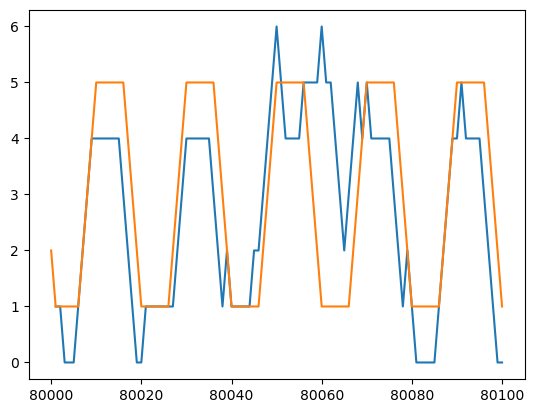

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.201457 | val MSE 0.133507
Epoch 02 | train MSE 0.103533 | val MSE 0.030579
Epoch 03 | train MSE 0.066643 | val MSE 0.017035
Epoch 04 | train MSE 0.064788 | val MSE 0.015620
Epoch 05 | train MSE 0.077360 | val MSE 0.016655
Epoch 06 | train MSE 0.061644 | val MSE 0.017046
Epoch 07 | train MSE 0.059609 | val MSE 0.017346
Epoch 08 | train MSE 0.058844 | val MSE 0.016839
Epoch 09 | train MSE 0.060587 | val MSE 0.017584
Epoch 10 | train MSE 0.056113 | val MSE 0.018134
Epoch 11 | train MSE 0.064100 | val MSE 0.018291
Epoch 12 | train MSE 0.050777 | val MSE 0.020182
Epoch 13 | train MSE 0.047914 | val MSE 0.019089
Epoch 14 | train MSE 0.045921 | val MSE 0.020279
Epoch 15 | train MSE 0.042988 | val MSE 0.020595
Epoch 16 | train MSE 0.040246 | val MSE 0.022217
Epoch 17 | train MSE 0.038732 | val MSE 0.020558
Epoch 18 | train MSE 0.036702 | val MSE 0.022390
Epoch 19 | train MSE 0.034231 | val MSE 0.023326
Epoch 20 | train MSE 0.03

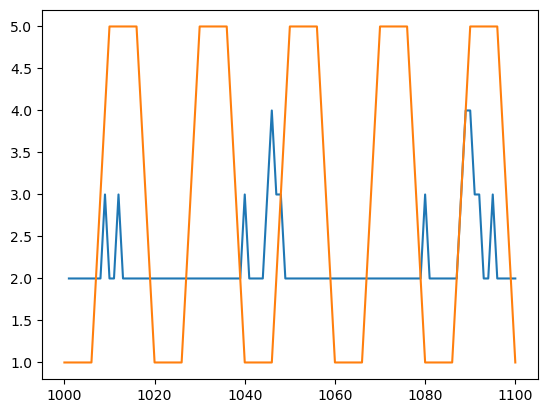

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.100774 | val MSE 0.041638
Epoch 02 | train MSE 0.064999 | val MSE 0.041327
Epoch 03 | train MSE 0.062416 | val MSE 0.040316
Epoch 04 | train MSE 0.060271 | val MSE 0.040216
Epoch 05 | train MSE 0.057963 | val MSE 0.040837
Epoch 06 | train MSE 0.055576 | val MSE 0.042643
Epoch 07 | train MSE 0.052078 | val MSE 0.041563
Epoch 08 | train MSE 0.049715 | val MSE 0.042398
Epoch 09 | train MSE 0.046457 | val MSE 0.043441
Epoch 10 | train MSE 0.043678 | val MSE 0.042798
Epoch 11 | train MSE 0.039015 | val MSE 0.049886
Epoch 12 | train MSE 0.036067 | val MSE 0.045585
Epoch 13 | train MSE 0.033990 | val MSE 0.045149
Epoch 14 | train MSE 0.031426 | val MSE 0.046414
Epoch 15 | train MSE 0.029447 | val MSE 0.044431
Epoch 16 | train MSE 0.026601 | val MSE 0.045498
Epoch 17 | train MSE 0.025995 | val MSE 0.044605
Epoch 18 | train MSE 0.024352 | val MSE 0.043140
Epoch 19 | train MSE 0.023569 | val MSE 0.043826
Epoch 20 | train MSE 0.

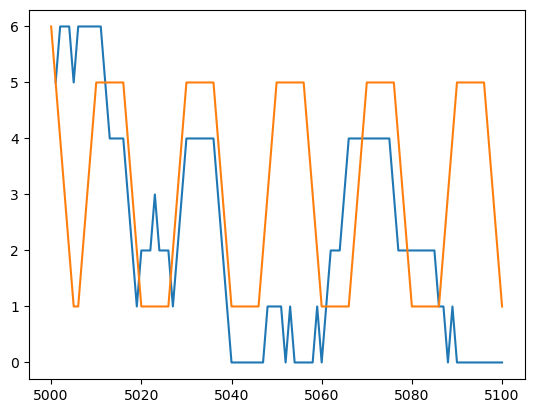

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.089087 | val MSE 0.074794
Epoch 02 | train MSE 0.076291 | val MSE 0.074794
Epoch 03 | train MSE 0.078256 | val MSE 0.074794
Epoch 04 | train MSE 0.077202 | val MSE 0.074794
Epoch 05 | train MSE 0.076860 | val MSE 0.074794
Epoch 06 | train MSE 0.076457 | val MSE 0.074794
Epoch 07 | train MSE 0.076850 | val MSE 0.074794
Epoch 08 | train MSE 0.077565 | val MSE 0.074794
Epoch 09 | train MSE 0.078534 | val MSE 0.074794
Epoch 10 | train MSE 0.077213 | val MSE 0.074794
Epoch 11 | train MSE 0.076782 | val MSE 0.074794
Epoch 12 | train MSE 0.077926 | val MSE 0.074794
Epoch 13 | train MSE 0.077091 | val MSE 0.074794
Epoch 14 | train MSE 0.077836 | val MSE 0.074794
Epoch 15 | train MSE 0.077719 | val MSE 0.074794
Epoch 16 | train MSE 0.077460 | val MSE 0.074794
Epoch 17 | train MSE 0.077419 | val MSE 0.074794
Epoch 18 | train MSE 0.077282 | val MSE 0.074794
Epoch 19 | train MSE 0.078353 | val MSE 0.074794
Epoch 20 | train MSE 0

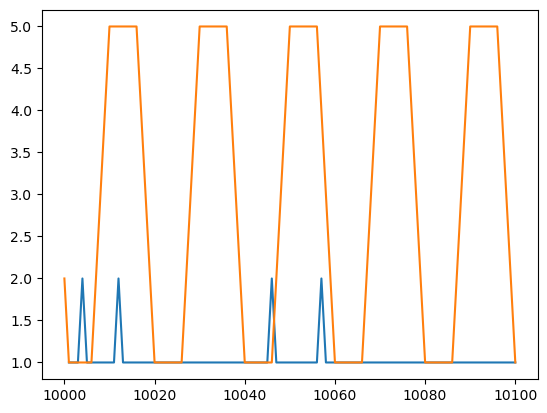

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.079573 | val MSE 0.070709
Epoch 02 | train MSE 0.077002 | val MSE 0.070709
Epoch 03 | train MSE 0.076410 | val MSE 0.070709
Epoch 04 | train MSE 0.076089 | val MSE 0.070709
Epoch 05 | train MSE 0.074546 | val MSE 0.070709
Epoch 06 | train MSE 0.075014 | val MSE 0.070709
Epoch 07 | train MSE 0.074117 | val MSE 0.070709
Epoch 08 | train MSE 0.075042 | val MSE 0.070709
Epoch 09 | train MSE 0.074795 | val MSE 0.070709
Epoch 10 | train MSE 0.076363 | val MSE 0.070709
Epoch 11 | train MSE 0.074738 | val MSE 0.070709
Epoch 12 | train MSE 0.075320 | val MSE 0.070709
Epoch 13 | train MSE 0.073923 | val MSE 0.070709
Epoch 14 | train MSE 0.074626 | val MSE 0.070709
Epoch 15 | train MSE 0.075465 | val MSE 0.070709
Epoch 16 | train MSE 0.073900 | val MSE 0.070709
Epoch 17 | train MSE 0.076148 | val MSE 0.070709
Epoch 18 | train MSE 0.077111 | val MSE 0.070709
Epoch 19 | train MSE 0.075090 | val MSE 0.070709
Epoch 20 | train MSE

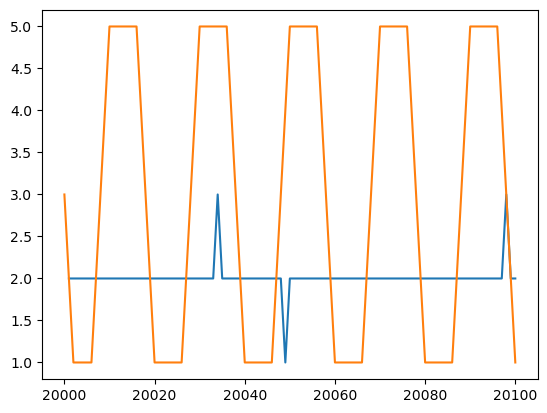

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077059 | val MSE 0.084512
Epoch 02 | train MSE 0.074704 | val MSE 0.084512
Epoch 03 | train MSE 0.074755 | val MSE 0.084512
Epoch 04 | train MSE 0.074631 | val MSE 0.084512
Epoch 05 | train MSE 0.074883 | val MSE 0.084512
Epoch 06 | train MSE 0.074985 | val MSE 0.084512
Epoch 07 | train MSE 0.074464 | val MSE 0.084512
Epoch 08 | train MSE 0.075309 | val MSE 0.084512
Epoch 09 | train MSE 0.075198 | val MSE 0.084511
Epoch 10 | train MSE 0.074127 | val MSE 0.076894
Epoch 11 | train MSE 0.052466 | val MSE 0.053824
Epoch 12 | train MSE 0.042660 | val MSE 0.051161
Epoch 13 | train MSE 0.038804 | val MSE 0.055344
Epoch 14 | train MSE 0.036424 | val MSE 0.053988
Epoch 15 | train MSE 0.033363 | val MSE 0.052194
Epoch 16 | train MSE 0.030674 | val MSE 0.056159
Epoch 17 | train MSE 0.029327 | val MSE 0.057269
Epoch 18 | train MSE 0.027906 | val MSE 0.056831
Epoch 19 | train MSE 0.026174 | val MSE 0.059983
Epoch 20 | train MSE

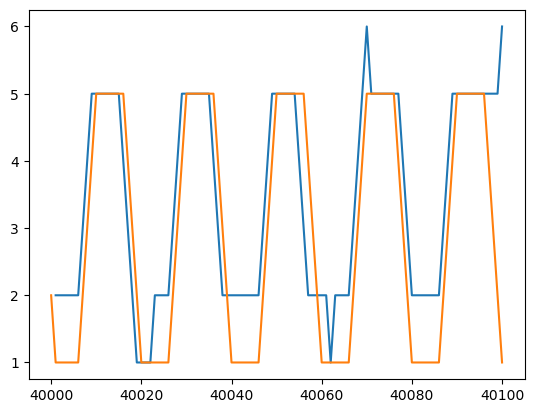

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078336 | val MSE 0.073697
Epoch 02 | train MSE 0.076826 | val MSE 0.073697
Epoch 03 | train MSE 0.076807 | val MSE 0.073697
Epoch 04 | train MSE 0.076817 | val MSE 0.073697
Epoch 05 | train MSE 0.076821 | val MSE 0.073697
Epoch 06 | train MSE 0.076779 | val MSE 0.073697
Epoch 07 | train MSE 0.076903 | val MSE 0.073697
Epoch 08 | train MSE 0.076789 | val MSE 0.073697
Epoch 09 | train MSE 0.076863 | val MSE 0.073697
Epoch 10 | train MSE 0.076809 | val MSE 0.073697
Epoch 11 | train MSE 0.076740 | val MSE 0.073697
Epoch 12 | train MSE 0.076762 | val MSE 0.073697
Epoch 13 | train MSE 0.076787 | val MSE 0.073697
Epoch 14 | train MSE 0.076831 | val MSE 0.073697
Epoch 15 | train MSE 0.076805 | val MSE 0.073697
Epoch 16 | train MSE 0.076766 | val MSE 0.073697
Epoch 17 | train MSE 0.076806 | val MSE 0.073697
Epoch 18 | train MSE 0.076817 | val MSE 0.073697
Epoch 19 | train MSE 0.076825 | val MSE 0.073697
Epoch 20 | train MSE

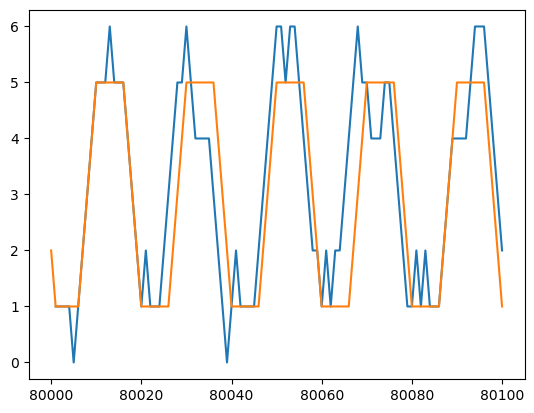

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.187923 | val MSE 0.130060
Epoch 02 | train MSE 0.101141 | val MSE 0.031999
Epoch 03 | train MSE 0.065223 | val MSE 0.017112
Epoch 04 | train MSE 0.062546 | val MSE 0.016732
Epoch 05 | train MSE 0.063323 | val MSE 0.017057
Epoch 06 | train MSE 0.059853 | val MSE 0.017866
Epoch 07 | train MSE 0.058635 | val MSE 0.018089
Epoch 08 | train MSE 0.056956 | val MSE 0.018190
Epoch 09 | train MSE 0.057799 | val MSE 0.018348
Epoch 10 | train MSE 0.052533 | val MSE 0.019051
Epoch 11 | train MSE 0.056503 | val MSE 0.019317
Epoch 12 | train MSE 0.048654 | val MSE 0.020044
Epoch 13 | train MSE 0.061932 | val MSE 0.019959
Epoch 14 | train MSE 0.050067 | val MSE 0.020743
Epoch 15 | train MSE 0.040091 | val MSE 0.019888
Epoch 16 | train MSE 0.038062 | val MSE 0.020656
Epoch 17 | train MSE 0.036494 | val MSE 0.020272
Epoch 18 | train MSE 0.034146 | val MSE 0.020668
Epoch 19 | train MSE 0.031361 | val MSE 0.022223
Epoch 20 | train MSE 0.02

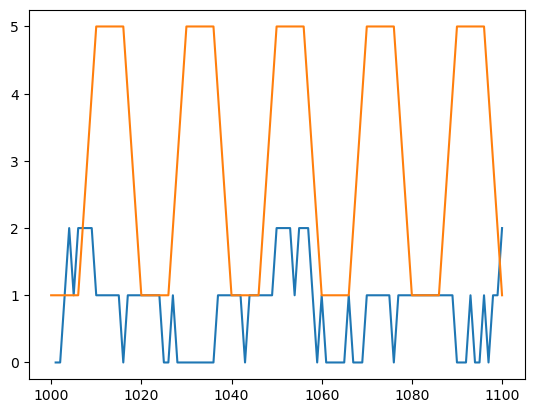

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.104355 | val MSE 0.041639
Epoch 02 | train MSE 0.064016 | val MSE 0.041346
Epoch 03 | train MSE 0.062162 | val MSE 0.041001
Epoch 04 | train MSE 0.060192 | val MSE 0.039880
Epoch 05 | train MSE 0.057659 | val MSE 0.039923
Epoch 06 | train MSE 0.055386 | val MSE 0.040473
Epoch 07 | train MSE 0.052507 | val MSE 0.041266
Epoch 08 | train MSE 0.050094 | val MSE 0.043328
Epoch 09 | train MSE 0.047019 | val MSE 0.042939
Epoch 10 | train MSE 0.043899 | val MSE 0.043873
Epoch 11 | train MSE 0.040097 | val MSE 0.045447
Epoch 12 | train MSE 0.036801 | val MSE 0.046625
Epoch 13 | train MSE 0.033428 | val MSE 0.045302
Epoch 14 | train MSE 0.031830 | val MSE 0.045605
Epoch 15 | train MSE 0.028363 | val MSE 0.048948
Epoch 16 | train MSE 0.027013 | val MSE 0.050979
Epoch 17 | train MSE 0.026153 | val MSE 0.046597
Epoch 18 | train MSE 0.025600 | val MSE 0.047988
Epoch 19 | train MSE 0.023906 | val MSE 0.047750
Epoch 20 | train MSE 0.

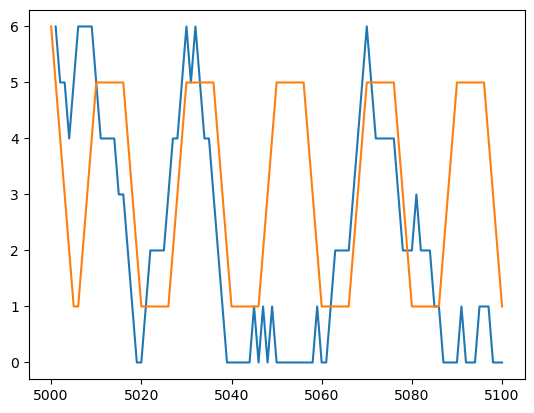

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.086958 | val MSE 0.074794
Epoch 02 | train MSE 0.077961 | val MSE 0.074794
Epoch 03 | train MSE 0.076846 | val MSE 0.074794
Epoch 04 | train MSE 0.076749 | val MSE 0.074794
Epoch 05 | train MSE 0.078154 | val MSE 0.074794
Epoch 06 | train MSE 0.077597 | val MSE 0.074794
Epoch 07 | train MSE 0.076764 | val MSE 0.074794
Epoch 08 | train MSE 0.077746 | val MSE 0.074794
Epoch 09 | train MSE 0.076880 | val MSE 0.074794
Epoch 10 | train MSE 0.077672 | val MSE 0.074794
Epoch 11 | train MSE 0.076472 | val MSE 0.074794
Epoch 12 | train MSE 0.077845 | val MSE 0.074794
Epoch 13 | train MSE 0.076845 | val MSE 0.074794
Epoch 14 | train MSE 0.077290 | val MSE 0.074794
Epoch 15 | train MSE 0.076875 | val MSE 0.074794
Epoch 16 | train MSE 0.076490 | val MSE 0.074794
Epoch 17 | train MSE 0.077101 | val MSE 0.074794
Epoch 18 | train MSE 0.078956 | val MSE 0.074794
Epoch 19 | train MSE 0.077081 | val MSE 0.074794
Epoch 20 | train MSE 0

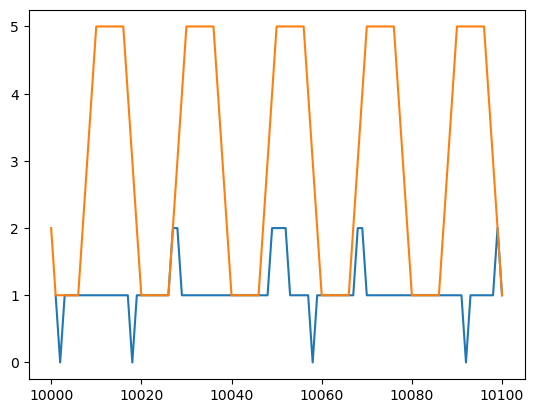

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.078555 | val MSE 0.070709
Epoch 02 | train MSE 0.076280 | val MSE 0.070709
Epoch 03 | train MSE 0.076083 | val MSE 0.070709
Epoch 04 | train MSE 0.075126 | val MSE 0.070709
Epoch 05 | train MSE 0.077129 | val MSE 0.070709
Epoch 06 | train MSE 0.073776 | val MSE 0.070709
Epoch 07 | train MSE 0.074378 | val MSE 0.070709
Epoch 08 | train MSE 0.074578 | val MSE 0.070709
Epoch 09 | train MSE 0.074660 | val MSE 0.070709
Epoch 10 | train MSE 0.076780 | val MSE 0.070709
Epoch 11 | train MSE 0.075375 | val MSE 0.070709
Epoch 12 | train MSE 0.074103 | val MSE 0.070709
Epoch 13 | train MSE 0.074937 | val MSE 0.070709
Epoch 14 | train MSE 0.074986 | val MSE 0.070709
Epoch 15 | train MSE 0.074654 | val MSE 0.070709
Epoch 16 | train MSE 0.074599 | val MSE 0.070709
Epoch 17 | train MSE 0.074410 | val MSE 0.070709
Epoch 18 | train MSE 0.076401 | val MSE 0.070709
Epoch 19 | train MSE 0.073508 | val MSE 0.070709
Epoch 20 | train MSE

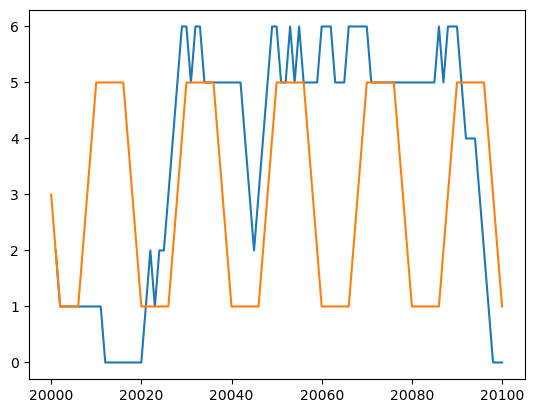

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077578 | val MSE 0.084512
Epoch 02 | train MSE 0.074747 | val MSE 0.084512
Epoch 03 | train MSE 0.074590 | val MSE 0.084512
Epoch 04 | train MSE 0.074609 | val MSE 0.084512
Epoch 05 | train MSE 0.074658 | val MSE 0.084512
Epoch 06 | train MSE 0.074906 | val MSE 0.084512
Epoch 07 | train MSE 0.075219 | val MSE 0.084512
Epoch 08 | train MSE 0.074534 | val MSE 0.084512
Epoch 09 | train MSE 0.075095 | val MSE 0.084512
Epoch 10 | train MSE 0.075050 | val MSE 0.084512
Epoch 11 | train MSE 0.074878 | val MSE 0.084512
Epoch 12 | train MSE 0.075277 | val MSE 0.084512
Epoch 13 | train MSE 0.074815 | val MSE 0.084512
Epoch 14 | train MSE 0.075053 | val MSE 0.084512
Epoch 15 | train MSE 0.074848 | val MSE 0.084512
Epoch 16 | train MSE 0.074453 | val MSE 0.084512
Epoch 17 | train MSE 0.074886 | val MSE 0.084512
Epoch 18 | train MSE 0.075069 | val MSE 0.084512
Epoch 19 | train MSE 0.074592 | val MSE 0.084512
Epoch 20 | train MSE

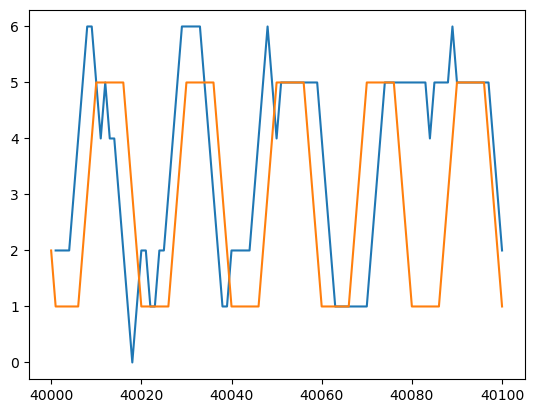

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078128 | val MSE 0.073697
Epoch 02 | train MSE 0.076826 | val MSE 0.073697
Epoch 03 | train MSE 0.076925 | val MSE 0.073697
Epoch 04 | train MSE 0.076802 | val MSE 0.073697
Epoch 05 | train MSE 0.076833 | val MSE 0.073697
Epoch 06 | train MSE 0.076830 | val MSE 0.073697
Epoch 07 | train MSE 0.076837 | val MSE 0.073697
Epoch 08 | train MSE 0.076813 | val MSE 0.073697
Epoch 09 | train MSE 0.076796 | val MSE 0.073697
Epoch 10 | train MSE 0.076822 | val MSE 0.073697
Epoch 11 | train MSE 0.076859 | val MSE 0.073697
Epoch 12 | train MSE 0.076759 | val MSE 0.073697
Epoch 13 | train MSE 0.076930 | val MSE 0.073697
Epoch 14 | train MSE 0.076869 | val MSE 0.073697
Epoch 15 | train MSE 0.076928 | val MSE 0.073695
Epoch 16 | train MSE 0.056930 | val MSE 0.044767
Epoch 17 | train MSE 0.044729 | val MSE 0.044210
Epoch 18 | train MSE 0.043084 | val MSE 0.045014
Epoch 19 | train MSE 0.041248 | val MSE 0.044720
Epoch 20 | train MSE

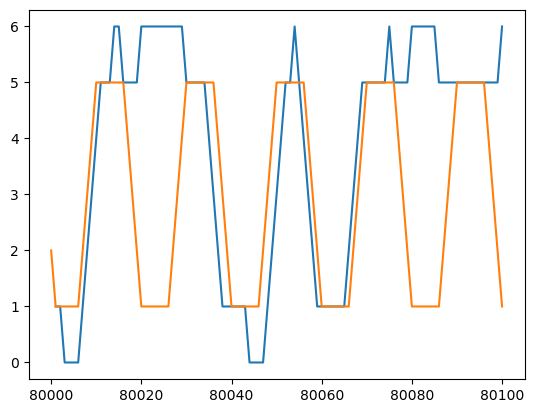

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.168849 | val MSE 0.105188
Epoch 02 | train MSE 0.089532 | val MSE 0.028632
Epoch 03 | train MSE 0.065100 | val MSE 0.016956
Epoch 04 | train MSE 0.063333 | val MSE 0.016181
Epoch 05 | train MSE 0.061776 | val MSE 0.016741
Epoch 06 | train MSE 0.060988 | val MSE 0.017439
Epoch 07 | train MSE 0.059023 | val MSE 0.017175
Epoch 08 | train MSE 0.057097 | val MSE 0.018184
Epoch 09 | train MSE 0.056135 | val MSE 0.017834
Epoch 10 | train MSE 0.054401 | val MSE 0.018237
Epoch 11 | train MSE 0.054562 | val MSE 0.019799
Epoch 12 | train MSE 0.049548 | val MSE 0.019739
Epoch 13 | train MSE 0.047587 | val MSE 0.020930
Epoch 14 | train MSE 0.044868 | val MSE 0.020538
Epoch 15 | train MSE 0.041457 | val MSE 0.021857
Epoch 16 | train MSE 0.039768 | val MSE 0.021322
Epoch 17 | train MSE 0.037854 | val MSE 0.021779
Epoch 18 | train MSE 0.035236 | val MSE 0.023014
Epoch 19 | train MSE 0.031197 | val MSE 0.024169
Epoch 20 | train MSE 0.03

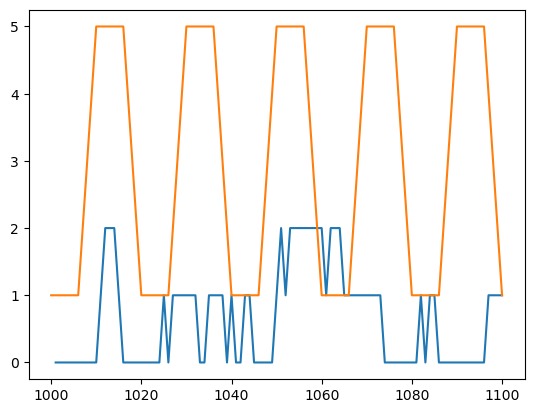

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.094398 | val MSE 0.040100
Epoch 02 | train MSE 0.063706 | val MSE 0.039737
Epoch 03 | train MSE 0.061108 | val MSE 0.040400
Epoch 04 | train MSE 0.058733 | val MSE 0.040422
Epoch 05 | train MSE 0.056673 | val MSE 0.042443
Epoch 06 | train MSE 0.052970 | val MSE 0.041252
Epoch 07 | train MSE 0.050898 | val MSE 0.041316
Epoch 08 | train MSE 0.048223 | val MSE 0.043120
Epoch 09 | train MSE 0.045000 | val MSE 0.045504
Epoch 10 | train MSE 0.041173 | val MSE 0.045684
Epoch 11 | train MSE 0.038420 | val MSE 0.044526
Epoch 12 | train MSE 0.034808 | val MSE 0.048221
Epoch 13 | train MSE 0.032698 | val MSE 0.046505
Epoch 14 | train MSE 0.030107 | val MSE 0.044820
Epoch 15 | train MSE 0.027896 | val MSE 0.045438
Epoch 16 | train MSE 0.027373 | val MSE 0.044849
Epoch 17 | train MSE 0.025185 | val MSE 0.047129
Epoch 18 | train MSE 0.024145 | val MSE 0.046387
Epoch 19 | train MSE 0.023396 | val MSE 0.045767
Epoch 20 | train MSE 0.

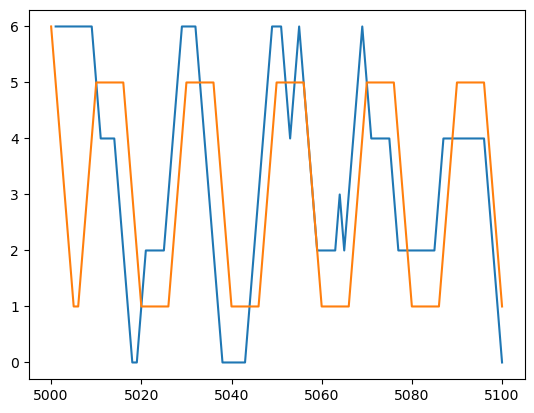

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.089917 | val MSE 0.074794
Epoch 02 | train MSE 0.076848 | val MSE 0.074794
Epoch 03 | train MSE 0.077348 | val MSE 0.074794
Epoch 04 | train MSE 0.077522 | val MSE 0.074794
Epoch 05 | train MSE 0.077517 | val MSE 0.074794
Epoch 06 | train MSE 0.076780 | val MSE 0.074794
Epoch 07 | train MSE 0.077370 | val MSE 0.074794
Epoch 08 | train MSE 0.077370 | val MSE 0.074794
Epoch 09 | train MSE 0.077233 | val MSE 0.074794
Epoch 10 | train MSE 0.077568 | val MSE 0.074794
Epoch 11 | train MSE 0.076655 | val MSE 0.074794
Epoch 12 | train MSE 0.077992 | val MSE 0.074794
Epoch 13 | train MSE 0.077181 | val MSE 0.074794
Epoch 14 | train MSE 0.077029 | val MSE 0.074794
Epoch 15 | train MSE 0.076992 | val MSE 0.074794
Epoch 16 | train MSE 0.078104 | val MSE 0.074794
Epoch 17 | train MSE 0.078482 | val MSE 0.074794
Epoch 18 | train MSE 0.076624 | val MSE 0.074794
Epoch 19 | train MSE 0.076738 | val MSE 0.074794
Epoch 20 | train MSE 0

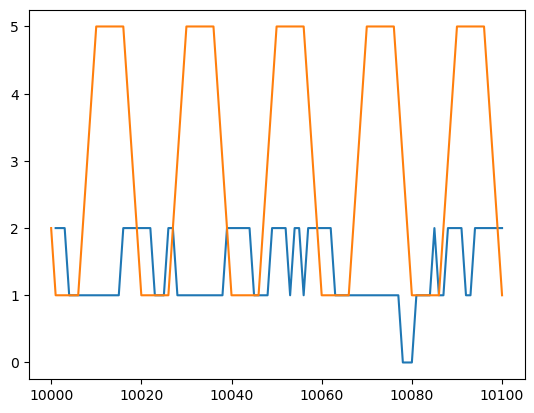

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.080688 | val MSE 0.070709
Epoch 02 | train MSE 0.074801 | val MSE 0.070709
Epoch 03 | train MSE 0.077307 | val MSE 0.070709
Epoch 04 | train MSE 0.076284 | val MSE 0.070709
Epoch 05 | train MSE 0.076441 | val MSE 0.070709
Epoch 06 | train MSE 0.075155 | val MSE 0.070709
Epoch 07 | train MSE 0.074534 | val MSE 0.070709
Epoch 08 | train MSE 0.076046 | val MSE 0.070709
Epoch 09 | train MSE 0.076474 | val MSE 0.070709
Epoch 10 | train MSE 0.075520 | val MSE 0.070709
Epoch 11 | train MSE 0.074662 | val MSE 0.070709
Epoch 12 | train MSE 0.078202 | val MSE 0.070709
Epoch 13 | train MSE 0.077336 | val MSE 0.070709
Epoch 14 | train MSE 0.075079 | val MSE 0.070709
Epoch 15 | train MSE 0.076612 | val MSE 0.070709
Epoch 16 | train MSE 0.074813 | val MSE 0.070709
Epoch 17 | train MSE 0.075627 | val MSE 0.070709
Epoch 18 | train MSE 0.075004 | val MSE 0.070709
Epoch 19 | train MSE 0.075989 | val MSE 0.070709
Epoch 20 | train MSE

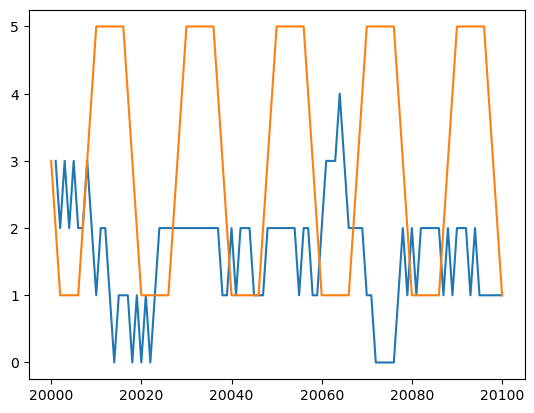

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077347 | val MSE 0.084512
Epoch 02 | train MSE 0.074601 | val MSE 0.084512
Epoch 03 | train MSE 0.074712 | val MSE 0.084512
Epoch 04 | train MSE 0.075047 | val MSE 0.084512
Epoch 05 | train MSE 0.075502 | val MSE 0.084512
Epoch 06 | train MSE 0.074867 | val MSE 0.084512
Epoch 07 | train MSE 0.074910 | val MSE 0.084512
Epoch 08 | train MSE 0.074709 | val MSE 0.084512
Epoch 09 | train MSE 0.074809 | val MSE 0.084512
Epoch 10 | train MSE 0.074510 | val MSE 0.084512
Epoch 11 | train MSE 0.074836 | val MSE 0.084512
Epoch 12 | train MSE 0.074687 | val MSE 0.084512
Epoch 13 | train MSE 0.074692 | val MSE 0.084512
Epoch 14 | train MSE 0.074704 | val MSE 0.084512
Epoch 15 | train MSE 0.074521 | val MSE 0.084512
Epoch 16 | train MSE 0.075184 | val MSE 0.084512
Epoch 17 | train MSE 0.074561 | val MSE 0.084512
Epoch 18 | train MSE 0.074518 | val MSE 0.084512
Epoch 19 | train MSE 0.074370 | val MSE 0.084512
Epoch 20 | train MSE

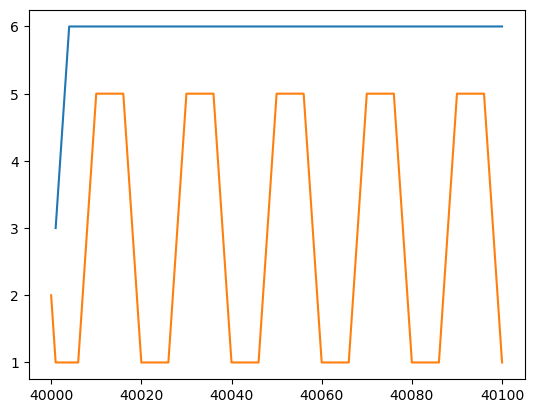

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078353 | val MSE 0.073697
Epoch 02 | train MSE 0.076774 | val MSE 0.073697
Epoch 03 | train MSE 0.076813 | val MSE 0.073697
Epoch 04 | train MSE 0.076815 | val MSE 0.073697
Epoch 05 | train MSE 0.076892 | val MSE 0.073697
Epoch 06 | train MSE 0.076832 | val MSE 0.073697
Epoch 07 | train MSE 0.076819 | val MSE 0.073697
Epoch 08 | train MSE 0.076779 | val MSE 0.073697
Epoch 09 | train MSE 0.076870 | val MSE 0.073697
Epoch 10 | train MSE 0.076830 | val MSE 0.073697
Epoch 11 | train MSE 0.076767 | val MSE 0.073697
Epoch 12 | train MSE 0.076785 | val MSE 0.073697
Epoch 13 | train MSE 0.076790 | val MSE 0.073697
Epoch 14 | train MSE 0.076892 | val MSE 0.073697
Epoch 15 | train MSE 0.076880 | val MSE 0.073697
Epoch 16 | train MSE 0.076771 | val MSE 0.073697
Epoch 17 | train MSE 0.076825 | val MSE 0.073697
Epoch 18 | train MSE 0.076892 | val MSE 0.073697
Epoch 19 | train MSE 0.076955 | val MSE 0.073697
Epoch 20 | train MSE

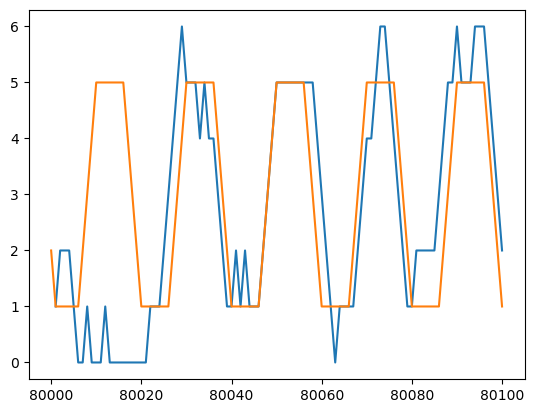

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.205797 | val MSE 0.153053
Epoch 02 | train MSE 0.116106 | val MSE 0.042206
Epoch 03 | train MSE 0.068889 | val MSE 0.017840
Epoch 04 | train MSE 0.067146 | val MSE 0.016409
Epoch 05 | train MSE 0.062668 | val MSE 0.016686
Epoch 06 | train MSE 0.061530 | val MSE 0.016738
Epoch 07 | train MSE 0.060491 | val MSE 0.017555
Epoch 08 | train MSE 0.058797 | val MSE 0.017426
Epoch 09 | train MSE 0.056654 | val MSE 0.017658
Epoch 10 | train MSE 0.059377 | val MSE 0.018168
Epoch 11 | train MSE 0.053711 | val MSE 0.018591
Epoch 12 | train MSE 0.051428 | val MSE 0.019127
Epoch 13 | train MSE 0.049483 | val MSE 0.018756
Epoch 14 | train MSE 0.046200 | val MSE 0.019998
Epoch 15 | train MSE 0.044636 | val MSE 0.020066
Epoch 16 | train MSE 0.041007 | val MSE 0.020092
Epoch 17 | train MSE 0.037444 | val MSE 0.020013
Epoch 18 | train MSE 0.037370 | val MSE 0.021775
Epoch 19 | train MSE 0.034526 | val MSE 0.019847
Epoch 20 | train MSE 0.03

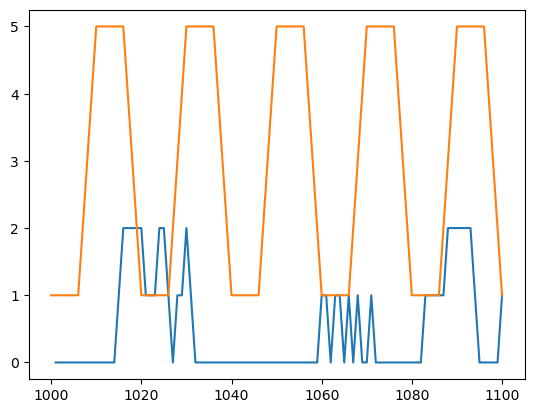

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.094568 | val MSE 0.041003
Epoch 02 | train MSE 0.064005 | val MSE 0.040941
Epoch 03 | train MSE 0.061746 | val MSE 0.040134
Epoch 04 | train MSE 0.059728 | val MSE 0.039962
Epoch 05 | train MSE 0.057138 | val MSE 0.039789
Epoch 06 | train MSE 0.054540 | val MSE 0.040843
Epoch 07 | train MSE 0.052476 | val MSE 0.039841
Epoch 08 | train MSE 0.049103 | val MSE 0.041017
Epoch 09 | train MSE 0.046072 | val MSE 0.042459
Epoch 10 | train MSE 0.042760 | val MSE 0.043361
Epoch 11 | train MSE 0.038586 | val MSE 0.040974
Epoch 12 | train MSE 0.035886 | val MSE 0.042956
Epoch 13 | train MSE 0.032113 | val MSE 0.046614
Epoch 14 | train MSE 0.030634 | val MSE 0.043368
Epoch 15 | train MSE 0.027967 | val MSE 0.044353
Epoch 16 | train MSE 0.027807 | val MSE 0.046725
Epoch 17 | train MSE 0.026639 | val MSE 0.047058
Epoch 18 | train MSE 0.023869 | val MSE 0.045840
Epoch 19 | train MSE 0.023574 | val MSE 0.047916
Epoch 20 | train MSE 0.

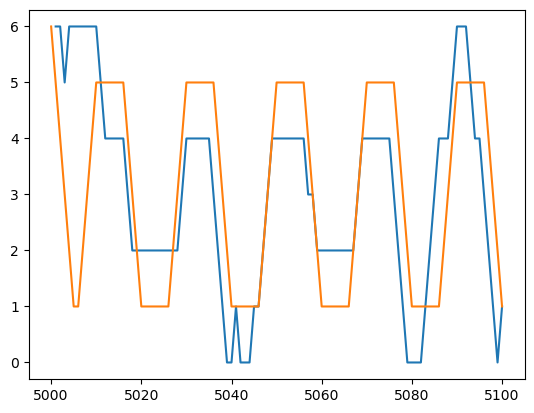

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.090108 | val MSE 0.074794
Epoch 02 | train MSE 0.076579 | val MSE 0.074794
Epoch 03 | train MSE 0.077207 | val MSE 0.074794
Epoch 04 | train MSE 0.077509 | val MSE 0.074794
Epoch 05 | train MSE 0.078245 | val MSE 0.074794
Epoch 06 | train MSE 0.077354 | val MSE 0.074794
Epoch 07 | train MSE 0.076622 | val MSE 0.074794
Epoch 08 | train MSE 0.078317 | val MSE 0.074794
Epoch 09 | train MSE 0.077077 | val MSE 0.074794
Epoch 10 | train MSE 0.077634 | val MSE 0.074794
Epoch 11 | train MSE 0.077008 | val MSE 0.074794
Epoch 12 | train MSE 0.077818 | val MSE 0.074794
Epoch 13 | train MSE 0.077414 | val MSE 0.074794
Epoch 14 | train MSE 0.076544 | val MSE 0.074794
Epoch 15 | train MSE 0.077178 | val MSE 0.074794
Epoch 16 | train MSE 0.076669 | val MSE 0.074794
Epoch 17 | train MSE 0.077309 | val MSE 0.074794
Epoch 18 | train MSE 0.077267 | val MSE 0.074794
Epoch 19 | train MSE 0.077919 | val MSE 0.074794
Epoch 20 | train MSE 0

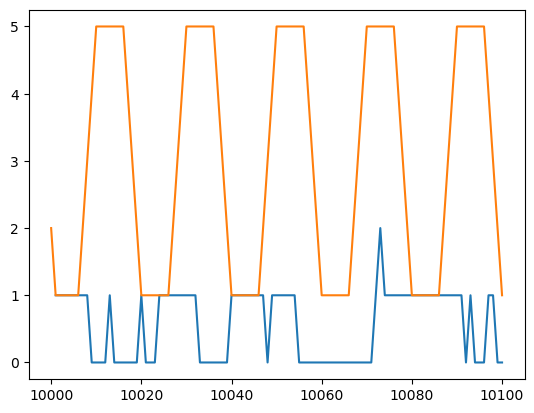

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.081462 | val MSE 0.070709
Epoch 02 | train MSE 0.074087 | val MSE 0.070709
Epoch 03 | train MSE 0.076401 | val MSE 0.070709
Epoch 04 | train MSE 0.076633 | val MSE 0.070709
Epoch 05 | train MSE 0.074648 | val MSE 0.070709
Epoch 06 | train MSE 0.075983 | val MSE 0.070709
Epoch 07 | train MSE 0.075812 | val MSE 0.070709
Epoch 08 | train MSE 0.074936 | val MSE 0.070709
Epoch 09 | train MSE 0.074101 | val MSE 0.070709
Epoch 10 | train MSE 0.074557 | val MSE 0.070709
Epoch 11 | train MSE 0.074114 | val MSE 0.070709
Epoch 12 | train MSE 0.075842 | val MSE 0.070709
Epoch 13 | train MSE 0.075783 | val MSE 0.070709
Epoch 14 | train MSE 0.074403 | val MSE 0.070709
Epoch 15 | train MSE 0.073843 | val MSE 0.070709
Epoch 16 | train MSE 0.074563 | val MSE 0.070709
Epoch 17 | train MSE 0.074781 | val MSE 0.070709
Epoch 18 | train MSE 0.073874 | val MSE 0.070709
Epoch 19 | train MSE 0.074996 | val MSE 0.070709
Epoch 20 | train MSE

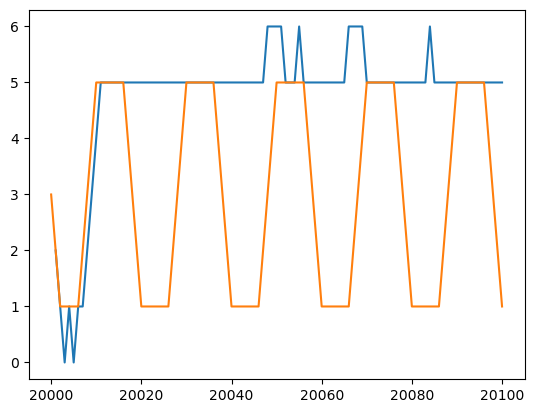

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077755 | val MSE 0.084512
Epoch 02 | train MSE 0.074412 | val MSE 0.084512
Epoch 03 | train MSE 0.075010 | val MSE 0.084512
Epoch 04 | train MSE 0.074733 | val MSE 0.084512
Epoch 05 | train MSE 0.075101 | val MSE 0.084512
Epoch 06 | train MSE 0.074690 | val MSE 0.084512
Epoch 07 | train MSE 0.074840 | val MSE 0.084512
Epoch 08 | train MSE 0.075131 | val MSE 0.084512
Epoch 09 | train MSE 0.074468 | val MSE 0.084512
Epoch 10 | train MSE 0.075405 | val MSE 0.084512
Epoch 11 | train MSE 0.074532 | val MSE 0.084512
Epoch 12 | train MSE 0.074897 | val MSE 0.084512
Epoch 13 | train MSE 0.074579 | val MSE 0.084512
Epoch 14 | train MSE 0.074922 | val MSE 0.084512
Epoch 15 | train MSE 0.075721 | val MSE 0.084512
Epoch 16 | train MSE 0.074570 | val MSE 0.084512
Epoch 17 | train MSE 0.075038 | val MSE 0.084512
Epoch 18 | train MSE 0.074682 | val MSE 0.084512
Epoch 19 | train MSE 0.074352 | val MSE 0.084512
Epoch 20 | train MSE

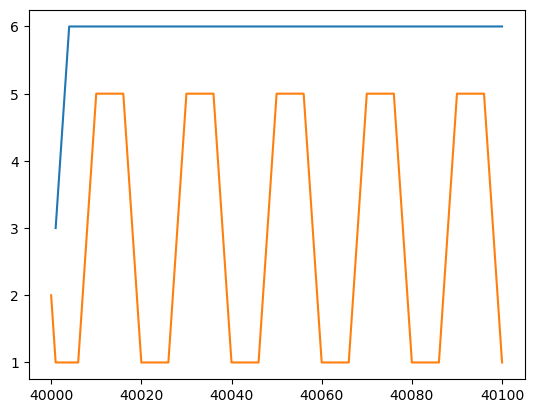

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.077923 | val MSE 0.073696
Epoch 02 | train MSE 0.076842 | val MSE 0.073696
Epoch 03 | train MSE 0.076742 | val MSE 0.073695
Epoch 04 | train MSE 0.066273 | val MSE 0.045082
Epoch 05 | train MSE 0.044880 | val MSE 0.043500
Epoch 06 | train MSE 0.042790 | val MSE 0.044509
Epoch 07 | train MSE 0.041434 | val MSE 0.045748
Epoch 08 | train MSE 0.039623 | val MSE 0.045534
Epoch 09 | train MSE 0.037555 | val MSE 0.047011
Epoch 10 | train MSE 0.036146 | val MSE 0.050191
Epoch 11 | train MSE 0.034617 | val MSE 0.048158
Epoch 12 | train MSE 0.032814 | val MSE 0.047785
Epoch 13 | train MSE 0.031655 | val MSE 0.047573
Epoch 14 | train MSE 0.029634 | val MSE 0.050659
Epoch 15 | train MSE 0.028081 | val MSE 0.050698
Epoch 16 | train MSE 0.026916 | val MSE 0.051527
Epoch 17 | train MSE 0.025804 | val MSE 0.052443
Epoch 18 | train MSE 0.024460 | val MSE 0.051964
Epoch 19 | train MSE 0.023653 | val MSE 0.053120
Epoch 20 | train MSE

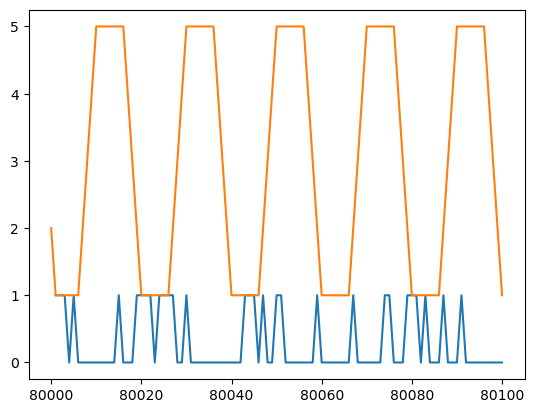

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.176874 | val MSE 0.114142
Epoch 02 | train MSE 0.092539 | val MSE 0.028312
Epoch 03 | train MSE 0.066006 | val MSE 0.016285
Epoch 04 | train MSE 0.066501 | val MSE 0.016420
Epoch 05 | train MSE 0.061685 | val MSE 0.017366
Epoch 06 | train MSE 0.062078 | val MSE 0.017754
Epoch 07 | train MSE 0.062936 | val MSE 0.017139
Epoch 08 | train MSE 0.058815 | val MSE 0.018243
Epoch 09 | train MSE 0.055245 | val MSE 0.018619
Epoch 10 | train MSE 0.052475 | val MSE 0.019073
Epoch 11 | train MSE 0.049357 | val MSE 0.018957
Epoch 12 | train MSE 0.048011 | val MSE 0.019853
Epoch 13 | train MSE 0.044285 | val MSE 0.021334
Epoch 14 | train MSE 0.040633 | val MSE 0.022528
Epoch 15 | train MSE 0.039283 | val MSE 0.020143
Epoch 16 | train MSE 0.035645 | val MSE 0.021162
Epoch 17 | train MSE 0.033921 | val MSE 0.020367
Epoch 18 | train MSE 0.031325 | val MSE 0.023642
Epoch 19 | train MSE 0.028293 | val MSE 0.021655
Epoch 20 | train MSE 0.02

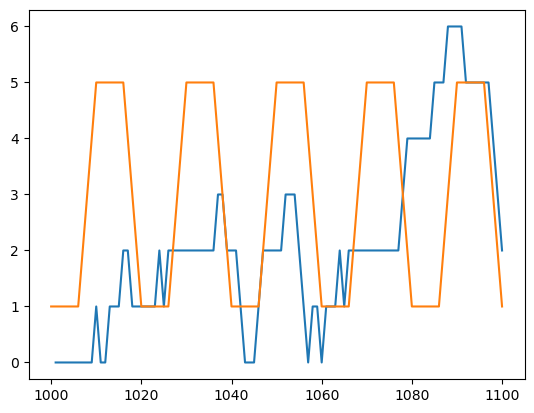

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.105200 | val MSE 0.042246
Epoch 02 | train MSE 0.064030 | val MSE 0.041852
Epoch 03 | train MSE 0.062734 | val MSE 0.040785
Epoch 04 | train MSE 0.060108 | val MSE 0.040299
Epoch 05 | train MSE 0.057175 | val MSE 0.040162
Epoch 06 | train MSE 0.054764 | val MSE 0.040396
Epoch 07 | train MSE 0.052551 | val MSE 0.042040
Epoch 08 | train MSE 0.049528 | val MSE 0.041299
Epoch 09 | train MSE 0.046421 | val MSE 0.043326
Epoch 10 | train MSE 0.043531 | val MSE 0.044719
Epoch 11 | train MSE 0.039991 | val MSE 0.043012
Epoch 12 | train MSE 0.036535 | val MSE 0.049622
Epoch 13 | train MSE 0.033333 | val MSE 0.048917
Epoch 14 | train MSE 0.030121 | val MSE 0.047948
Epoch 15 | train MSE 0.029190 | val MSE 0.048450
Epoch 16 | train MSE 0.027690 | val MSE 0.051157
Epoch 17 | train MSE 0.024884 | val MSE 0.050430
Epoch 18 | train MSE 0.024862 | val MSE 0.049554
Epoch 19 | train MSE 0.024366 | val MSE 0.051016
Epoch 20 | train MSE 0.

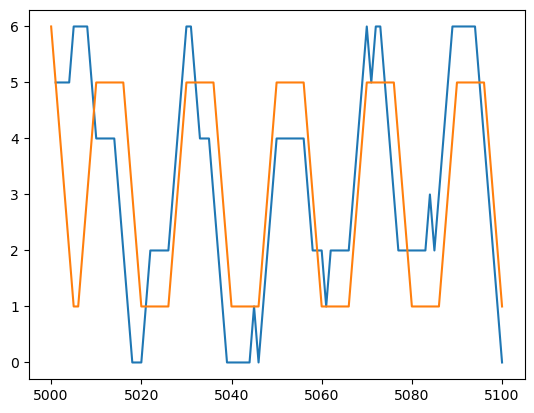

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.086431 | val MSE 0.074794
Epoch 02 | train MSE 0.076948 | val MSE 0.074794
Epoch 03 | train MSE 0.077606 | val MSE 0.074794
Epoch 04 | train MSE 0.077696 | val MSE 0.074794
Epoch 05 | train MSE 0.077104 | val MSE 0.074794
Epoch 06 | train MSE 0.077119 | val MSE 0.074794
Epoch 07 | train MSE 0.077055 | val MSE 0.074794
Epoch 08 | train MSE 0.077331 | val MSE 0.074794
Epoch 09 | train MSE 0.076836 | val MSE 0.074794
Epoch 10 | train MSE 0.076589 | val MSE 0.074794
Epoch 11 | train MSE 0.077028 | val MSE 0.074794
Epoch 12 | train MSE 0.077300 | val MSE 0.074794
Epoch 13 | train MSE 0.076924 | val MSE 0.074794
Epoch 14 | train MSE 0.077749 | val MSE 0.074794
Epoch 15 | train MSE 0.077663 | val MSE 0.074794
Epoch 16 | train MSE 0.076779 | val MSE 0.074794
Epoch 17 | train MSE 0.076782 | val MSE 0.074794
Epoch 18 | train MSE 0.078486 | val MSE 0.074794
Epoch 19 | train MSE 0.077059 | val MSE 0.074794
Epoch 20 | train MSE 0

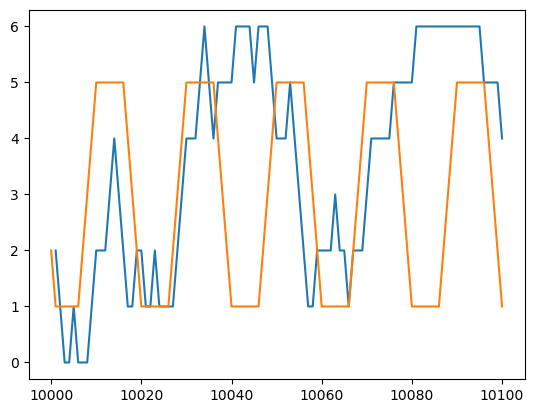

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.079386 | val MSE 0.070709
Epoch 02 | train MSE 0.075245 | val MSE 0.070709
Epoch 03 | train MSE 0.074133 | val MSE 0.070709
Epoch 04 | train MSE 0.075636 | val MSE 0.070709
Epoch 05 | train MSE 0.074277 | val MSE 0.070709
Epoch 06 | train MSE 0.074673 | val MSE 0.070709
Epoch 07 | train MSE 0.075843 | val MSE 0.070709
Epoch 08 | train MSE 0.074010 | val MSE 0.070709
Epoch 09 | train MSE 0.074337 | val MSE 0.070709
Epoch 10 | train MSE 0.076128 | val MSE 0.070709
Epoch 11 | train MSE 0.075530 | val MSE 0.070709
Epoch 12 | train MSE 0.074391 | val MSE 0.070709
Epoch 13 | train MSE 0.075511 | val MSE 0.070709
Epoch 14 | train MSE 0.077123 | val MSE 0.070709
Epoch 15 | train MSE 0.075106 | val MSE 0.070709
Epoch 16 | train MSE 0.074290 | val MSE 0.070709
Epoch 17 | train MSE 0.073965 | val MSE 0.070709
Epoch 18 | train MSE 0.073978 | val MSE 0.070709
Epoch 19 | train MSE 0.075963 | val MSE 0.070709
Epoch 20 | train MSE

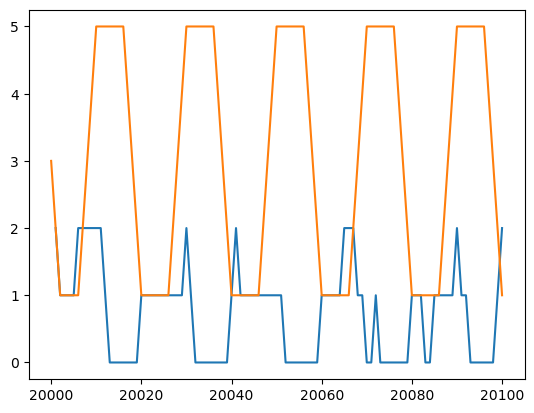

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077051 | val MSE 0.084512
Epoch 02 | train MSE 0.074408 | val MSE 0.084512
Epoch 03 | train MSE 0.074950 | val MSE 0.084512
Epoch 04 | train MSE 0.074691 | val MSE 0.084512
Epoch 05 | train MSE 0.074957 | val MSE 0.084512
Epoch 06 | train MSE 0.074795 | val MSE 0.084512
Epoch 07 | train MSE 0.074922 | val MSE 0.084512
Epoch 08 | train MSE 0.074989 | val MSE 0.084512
Epoch 09 | train MSE 0.074569 | val MSE 0.084512
Epoch 10 | train MSE 0.075180 | val MSE 0.084512
Epoch 11 | train MSE 0.075050 | val MSE 0.084512
Epoch 12 | train MSE 0.075153 | val MSE 0.084512
Epoch 13 | train MSE 0.074314 | val MSE 0.084512
Epoch 14 | train MSE 0.074399 | val MSE 0.084512
Epoch 15 | train MSE 0.074751 | val MSE 0.084512
Epoch 16 | train MSE 0.075181 | val MSE 0.084512
Epoch 17 | train MSE 0.074604 | val MSE 0.084512
Epoch 18 | train MSE 0.074835 | val MSE 0.084512
Epoch 19 | train MSE 0.075029 | val MSE 0.084512
Epoch 20 | train MSE

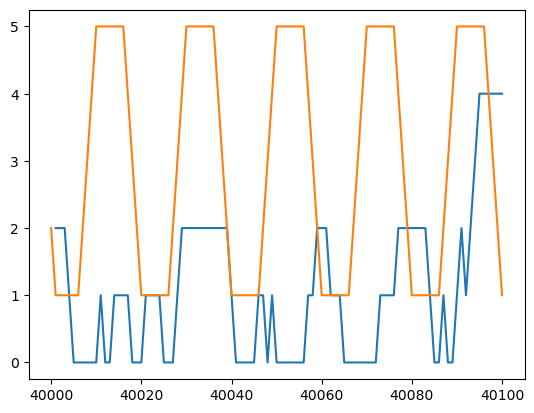

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078065 | val MSE 0.073697
Epoch 02 | train MSE 0.076856 | val MSE 0.073697
Epoch 03 | train MSE 0.076791 | val MSE 0.073697
Epoch 04 | train MSE 0.076812 | val MSE 0.073697
Epoch 05 | train MSE 0.076798 | val MSE 0.073697
Epoch 06 | train MSE 0.076784 | val MSE 0.073697
Epoch 07 | train MSE 0.076866 | val MSE 0.073697
Epoch 08 | train MSE 0.076926 | val MSE 0.073697
Epoch 09 | train MSE 0.076792 | val MSE 0.073697
Epoch 10 | train MSE 0.076844 | val MSE 0.073697
Epoch 11 | train MSE 0.076814 | val MSE 0.073697
Epoch 12 | train MSE 0.076764 | val MSE 0.073697
Epoch 13 | train MSE 0.076887 | val MSE 0.073697
Epoch 14 | train MSE 0.076829 | val MSE 0.073697
Epoch 15 | train MSE 0.076839 | val MSE 0.073697
Epoch 16 | train MSE 0.076844 | val MSE 0.073697
Epoch 17 | train MSE 0.076817 | val MSE 0.073697
Epoch 18 | train MSE 0.076873 | val MSE 0.073697
Epoch 19 | train MSE 0.076887 | val MSE 0.073697
Epoch 20 | train MSE

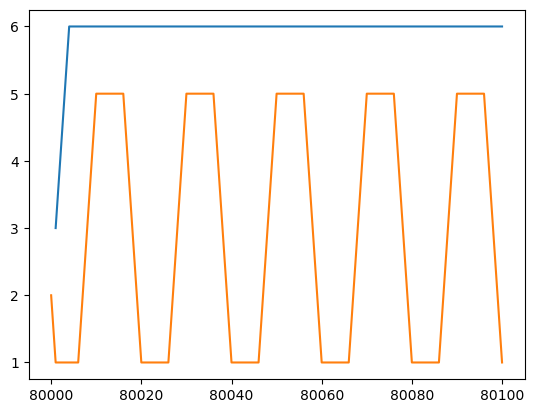

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.176808 | val MSE 0.107518
Epoch 02 | train MSE 0.089834 | val MSE 0.027172
Epoch 03 | train MSE 0.067921 | val MSE 0.016192
Epoch 04 | train MSE 0.063110 | val MSE 0.016330
Epoch 05 | train MSE 0.063609 | val MSE 0.016522
Epoch 06 | train MSE 0.060939 | val MSE 0.017436
Epoch 07 | train MSE 0.059218 | val MSE 0.017530
Epoch 08 | train MSE 0.059377 | val MSE 0.017607
Epoch 09 | train MSE 0.065951 | val MSE 0.018083
Epoch 10 | train MSE 0.075745 | val MSE 0.019004
Epoch 11 | train MSE 0.053231 | val MSE 0.019399
Epoch 12 | train MSE 0.049836 | val MSE 0.018782
Epoch 13 | train MSE 0.065428 | val MSE 0.020009
Epoch 14 | train MSE 0.044753 | val MSE 0.021373
Epoch 15 | train MSE 0.044337 | val MSE 0.021235
Epoch 16 | train MSE 0.039941 | val MSE 0.021327
Epoch 17 | train MSE 0.037046 | val MSE 0.022728
Epoch 18 | train MSE 0.035598 | val MSE 0.021861
Epoch 19 | train MSE 0.034333 | val MSE 0.023678
Epoch 20 | train MSE 0.03

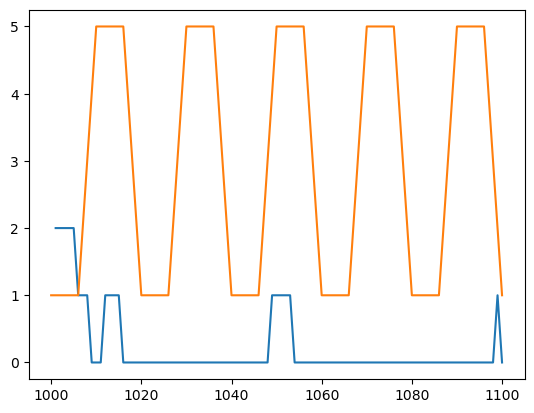

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.094310 | val MSE 0.040297
Epoch 02 | train MSE 0.064208 | val MSE 0.040115
Epoch 03 | train MSE 0.062222 | val MSE 0.039923
Epoch 04 | train MSE 0.060256 | val MSE 0.040125
Epoch 05 | train MSE 0.057231 | val MSE 0.040121
Epoch 06 | train MSE 0.054929 | val MSE 0.040224
Epoch 07 | train MSE 0.051504 | val MSE 0.041211
Epoch 08 | train MSE 0.049304 | val MSE 0.041753
Epoch 09 | train MSE 0.044847 | val MSE 0.042377
Epoch 10 | train MSE 0.041920 | val MSE 0.043310
Epoch 11 | train MSE 0.038708 | val MSE 0.048535
Epoch 12 | train MSE 0.034959 | val MSE 0.046086
Epoch 13 | train MSE 0.033620 | val MSE 0.046537
Epoch 14 | train MSE 0.030678 | val MSE 0.045894
Epoch 15 | train MSE 0.029071 | val MSE 0.051359
Epoch 16 | train MSE 0.027500 | val MSE 0.048336
Epoch 17 | train MSE 0.025156 | val MSE 0.048623
Epoch 18 | train MSE 0.024443 | val MSE 0.048420
Epoch 19 | train MSE 0.023748 | val MSE 0.048364
Epoch 20 | train MSE 0.

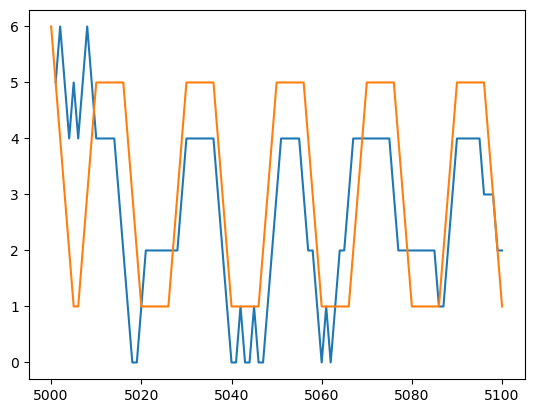

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.086016 | val MSE 0.074794
Epoch 02 | train MSE 0.076625 | val MSE 0.074794
Epoch 03 | train MSE 0.076790 | val MSE 0.074794
Epoch 04 | train MSE 0.077552 | val MSE 0.074794
Epoch 05 | train MSE 0.076852 | val MSE 0.074794
Epoch 06 | train MSE 0.078451 | val MSE 0.074794
Epoch 07 | train MSE 0.077046 | val MSE 0.074794
Epoch 08 | train MSE 0.076886 | val MSE 0.074794
Epoch 09 | train MSE 0.077696 | val MSE 0.074794
Epoch 10 | train MSE 0.076901 | val MSE 0.074794
Epoch 11 | train MSE 0.077029 | val MSE 0.074794
Epoch 12 | train MSE 0.076949 | val MSE 0.074794
Epoch 13 | train MSE 0.076374 | val MSE 0.074794
Epoch 14 | train MSE 0.077392 | val MSE 0.074794
Epoch 15 | train MSE 0.076826 | val MSE 0.074794
Epoch 16 | train MSE 0.077156 | val MSE 0.074794
Epoch 17 | train MSE 0.078067 | val MSE 0.074794
Epoch 18 | train MSE 0.076928 | val MSE 0.074794
Epoch 19 | train MSE 0.078127 | val MSE 0.074794
Epoch 20 | train MSE 0

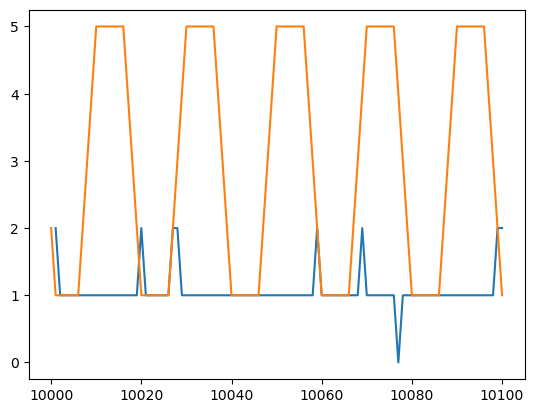

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.079174 | val MSE 0.070709
Epoch 02 | train MSE 0.074801 | val MSE 0.070709
Epoch 03 | train MSE 0.076002 | val MSE 0.070709
Epoch 04 | train MSE 0.075602 | val MSE 0.070709
Epoch 05 | train MSE 0.075584 | val MSE 0.070709
Epoch 06 | train MSE 0.075129 | val MSE 0.070709
Epoch 07 | train MSE 0.075279 | val MSE 0.070709
Epoch 08 | train MSE 0.075203 | val MSE 0.070709
Epoch 09 | train MSE 0.075365 | val MSE 0.070709
Epoch 10 | train MSE 0.076935 | val MSE 0.070709
Epoch 11 | train MSE 0.074805 | val MSE 0.070709
Epoch 12 | train MSE 0.075507 | val MSE 0.070709
Epoch 13 | train MSE 0.074012 | val MSE 0.070709
Epoch 14 | train MSE 0.075136 | val MSE 0.070709
Epoch 15 | train MSE 0.075439 | val MSE 0.070709
Epoch 16 | train MSE 0.075075 | val MSE 0.070709
Epoch 17 | train MSE 0.076447 | val MSE 0.070709
Epoch 18 | train MSE 0.076693 | val MSE 0.070709
Epoch 19 | train MSE 0.075615 | val MSE 0.070709
Epoch 20 | train MSE

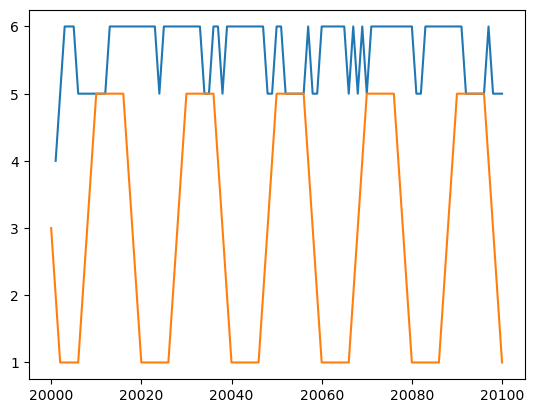

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077734 | val MSE 0.084512
Epoch 02 | train MSE 0.074854 | val MSE 0.084512
Epoch 03 | train MSE 0.074707 | val MSE 0.084512
Epoch 04 | train MSE 0.075253 | val MSE 0.084512
Epoch 05 | train MSE 0.074843 | val MSE 0.084512
Epoch 06 | train MSE 0.074825 | val MSE 0.084512
Epoch 07 | train MSE 0.074558 | val MSE 0.084512
Epoch 08 | train MSE 0.074515 | val MSE 0.084512
Epoch 09 | train MSE 0.074933 | val MSE 0.084512
Epoch 10 | train MSE 0.074597 | val MSE 0.084512
Epoch 11 | train MSE 0.074976 | val MSE 0.084512
Epoch 12 | train MSE 0.074327 | val MSE 0.084512
Epoch 13 | train MSE 0.074966 | val MSE 0.084512
Epoch 14 | train MSE 0.074739 | val MSE 0.084512
Epoch 15 | train MSE 0.074983 | val MSE 0.084512
Epoch 16 | train MSE 0.075034 | val MSE 0.084512
Epoch 17 | train MSE 0.075557 | val MSE 0.084512
Epoch 18 | train MSE 0.075578 | val MSE 0.084512
Epoch 19 | train MSE 0.075132 | val MSE 0.084512
Epoch 20 | train MSE

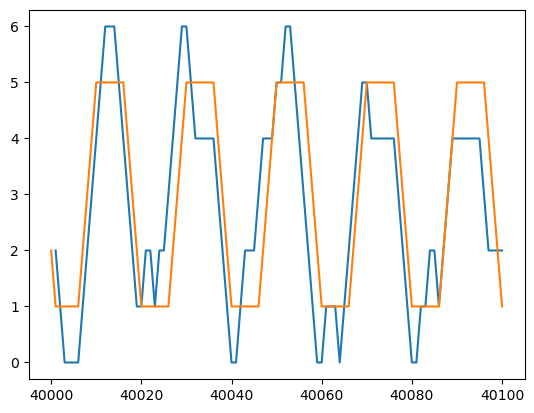

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078412 | val MSE 0.073697
Epoch 02 | train MSE 0.076929 | val MSE 0.073697
Epoch 03 | train MSE 0.076812 | val MSE 0.073697
Epoch 04 | train MSE 0.076896 | val MSE 0.073697
Epoch 05 | train MSE 0.076863 | val MSE 0.073697
Epoch 06 | train MSE 0.076875 | val MSE 0.073697
Epoch 07 | train MSE 0.076887 | val MSE 0.073697
Epoch 08 | train MSE 0.076803 | val MSE 0.073697
Epoch 09 | train MSE 0.076888 | val MSE 0.073697
Epoch 10 | train MSE 0.076873 | val MSE 0.073697
Epoch 11 | train MSE 0.076805 | val MSE 0.073697
Epoch 12 | train MSE 0.076757 | val MSE 0.073697
Epoch 13 | train MSE 0.076858 | val MSE 0.073697
Epoch 14 | train MSE 0.076816 | val MSE 0.073697
Epoch 15 | train MSE 0.076925 | val MSE 0.073697
Epoch 16 | train MSE 0.076925 | val MSE 0.073697
Epoch 17 | train MSE 0.076798 | val MSE 0.073697
Epoch 18 | train MSE 0.076863 | val MSE 0.073697
Epoch 19 | train MSE 0.076835 | val MSE 0.073697
Epoch 20 | train MSE

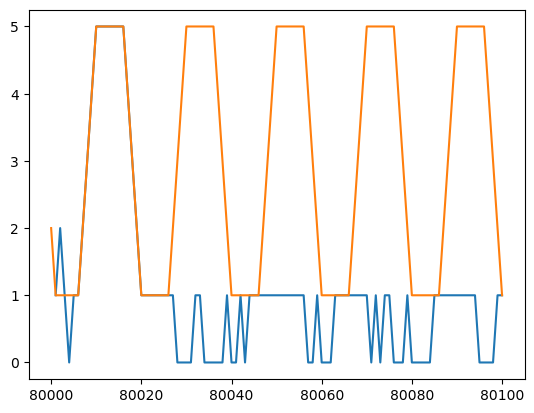

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.185944 | val MSE 0.120834
Epoch 02 | train MSE 0.095166 | val MSE 0.027893
Epoch 03 | train MSE 0.064460 | val MSE 0.016051
Epoch 04 | train MSE 0.063242 | val MSE 0.015973
Epoch 05 | train MSE 0.064499 | val MSE 0.016667
Epoch 06 | train MSE 0.060064 | val MSE 0.017571
Epoch 07 | train MSE 0.058759 | val MSE 0.016708
Epoch 08 | train MSE 0.070863 | val MSE 0.017588
Epoch 09 | train MSE 0.055838 | val MSE 0.019011
Epoch 10 | train MSE 0.054213 | val MSE 0.018603
Epoch 11 | train MSE 0.051841 | val MSE 0.018890
Epoch 12 | train MSE 0.050174 | val MSE 0.019488
Epoch 13 | train MSE 0.048581 | val MSE 0.019754
Epoch 14 | train MSE 0.045920 | val MSE 0.020620
Epoch 15 | train MSE 0.044962 | val MSE 0.020665
Epoch 16 | train MSE 0.041110 | val MSE 0.021867
Epoch 17 | train MSE 0.039032 | val MSE 0.021623
Epoch 18 | train MSE 0.037630 | val MSE 0.022408
Epoch 19 | train MSE 0.035116 | val MSE 0.022687
Epoch 20 | train MSE 0.03

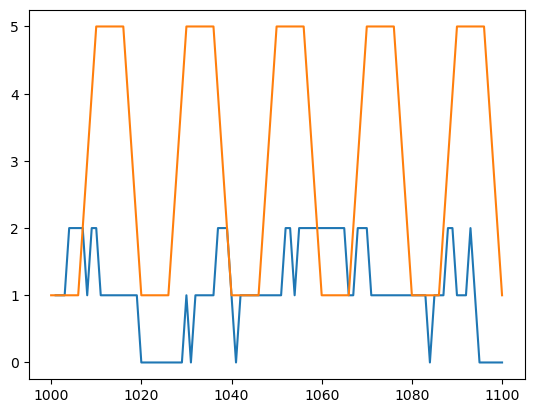

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.099276 | val MSE 0.041280
Epoch 02 | train MSE 0.064230 | val MSE 0.040283
Epoch 03 | train MSE 0.062568 | val MSE 0.040942
Epoch 04 | train MSE 0.059985 | val MSE 0.040110
Epoch 05 | train MSE 0.057611 | val MSE 0.041249
Epoch 06 | train MSE 0.054954 | val MSE 0.042155
Epoch 07 | train MSE 0.052834 | val MSE 0.042078
Epoch 08 | train MSE 0.050249 | val MSE 0.044875
Epoch 09 | train MSE 0.047617 | val MSE 0.043925
Epoch 10 | train MSE 0.044578 | val MSE 0.042707
Epoch 11 | train MSE 0.041002 | val MSE 0.045120
Epoch 12 | train MSE 0.037378 | val MSE 0.043802
Epoch 13 | train MSE 0.035567 | val MSE 0.044798
Epoch 14 | train MSE 0.032182 | val MSE 0.045377
Epoch 15 | train MSE 0.029874 | val MSE 0.046287
Epoch 16 | train MSE 0.029043 | val MSE 0.047837
Epoch 17 | train MSE 0.026617 | val MSE 0.045355
Epoch 18 | train MSE 0.025327 | val MSE 0.045445
Epoch 19 | train MSE 0.023292 | val MSE 0.046768
Epoch 20 | train MSE 0.

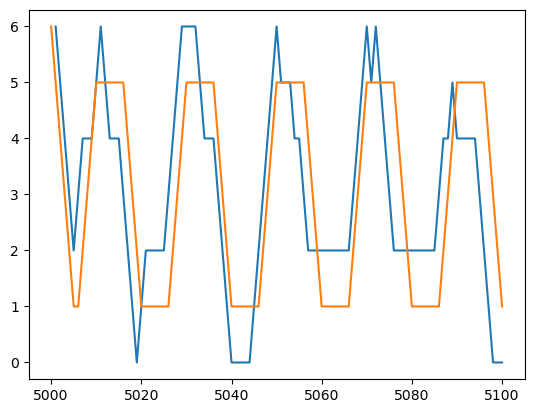

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.087022 | val MSE 0.074794
Epoch 02 | train MSE 0.078446 | val MSE 0.074794
Epoch 03 | train MSE 0.076752 | val MSE 0.074794
Epoch 04 | train MSE 0.076947 | val MSE 0.074794
Epoch 05 | train MSE 0.077759 | val MSE 0.074794
Epoch 06 | train MSE 0.077413 | val MSE 0.074794
Epoch 07 | train MSE 0.077656 | val MSE 0.074794
Epoch 08 | train MSE 0.077076 | val MSE 0.074794
Epoch 09 | train MSE 0.077268 | val MSE 0.074794
Epoch 10 | train MSE 0.077394 | val MSE 0.074794
Epoch 11 | train MSE 0.077595 | val MSE 0.074794
Epoch 12 | train MSE 0.078035 | val MSE 0.074794
Epoch 13 | train MSE 0.077223 | val MSE 0.074794
Epoch 14 | train MSE 0.077892 | val MSE 0.074794
Epoch 15 | train MSE 0.078598 | val MSE 0.074794
Epoch 16 | train MSE 0.076926 | val MSE 0.074794
Epoch 17 | train MSE 0.076110 | val MSE 0.074794
Epoch 18 | train MSE 0.077164 | val MSE 0.074794
Epoch 19 | train MSE 0.077529 | val MSE 0.074794
Epoch 20 | train MSE 0

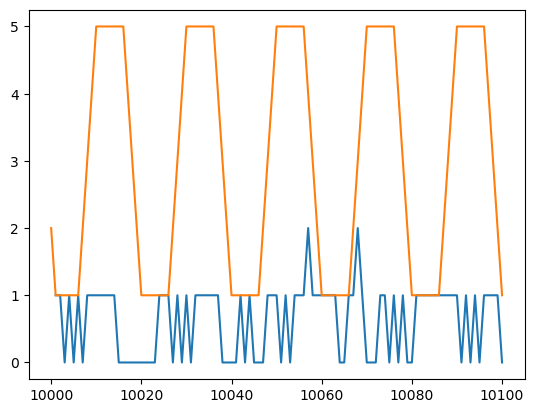

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.079321 | val MSE 0.070709
Epoch 02 | train MSE 0.074055 | val MSE 0.070709
Epoch 03 | train MSE 0.075288 | val MSE 0.070709
Epoch 04 | train MSE 0.075540 | val MSE 0.070709
Epoch 05 | train MSE 0.075486 | val MSE 0.070709
Epoch 06 | train MSE 0.075507 | val MSE 0.070709
Epoch 07 | train MSE 0.074012 | val MSE 0.070709
Epoch 08 | train MSE 0.076429 | val MSE 0.070709
Epoch 09 | train MSE 0.074750 | val MSE 0.070709
Epoch 10 | train MSE 0.076275 | val MSE 0.070709
Epoch 11 | train MSE 0.073820 | val MSE 0.070709
Epoch 12 | train MSE 0.075465 | val MSE 0.070709
Epoch 13 | train MSE 0.076109 | val MSE 0.070709
Epoch 14 | train MSE 0.074882 | val MSE 0.070709
Epoch 15 | train MSE 0.075733 | val MSE 0.070709
Epoch 16 | train MSE 0.075067 | val MSE 0.070709
Epoch 17 | train MSE 0.073999 | val MSE 0.070709
Epoch 18 | train MSE 0.075035 | val MSE 0.070709
Epoch 19 | train MSE 0.074542 | val MSE 0.070709
Epoch 20 | train MSE

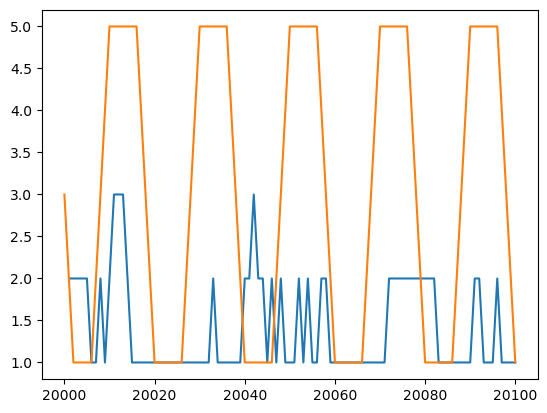

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077265 | val MSE 0.084512
Epoch 02 | train MSE 0.074753 | val MSE 0.084512
Epoch 03 | train MSE 0.074407 | val MSE 0.084512
Epoch 04 | train MSE 0.074554 | val MSE 0.084512
Epoch 05 | train MSE 0.074598 | val MSE 0.084512
Epoch 06 | train MSE 0.074787 | val MSE 0.084512
Epoch 07 | train MSE 0.074595 | val MSE 0.084512
Epoch 08 | train MSE 0.075247 | val MSE 0.084512
Epoch 09 | train MSE 0.074688 | val MSE 0.084512
Epoch 10 | train MSE 0.074765 | val MSE 0.084512
Epoch 11 | train MSE 0.074654 | val MSE 0.084512
Epoch 12 | train MSE 0.074918 | val MSE 0.084512
Epoch 13 | train MSE 0.075010 | val MSE 0.084512
Epoch 14 | train MSE 0.074829 | val MSE 0.084512
Epoch 15 | train MSE 0.074578 | val MSE 0.084512
Epoch 16 | train MSE 0.074791 | val MSE 0.084512
Epoch 17 | train MSE 0.074820 | val MSE 0.084512
Epoch 18 | train MSE 0.074923 | val MSE 0.084512
Epoch 19 | train MSE 0.074957 | val MSE 0.084512
Epoch 20 | train MSE

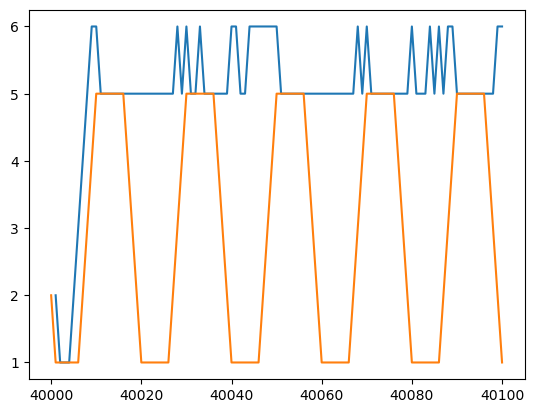

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078619 | val MSE 0.073697
Epoch 02 | train MSE 0.076908 | val MSE 0.073697
Epoch 03 | train MSE 0.076922 | val MSE 0.073697
Epoch 04 | train MSE 0.076805 | val MSE 0.073697
Epoch 05 | train MSE 0.076813 | val MSE 0.073697
Epoch 06 | train MSE 0.076853 | val MSE 0.073697
Epoch 07 | train MSE 0.076905 | val MSE 0.073697
Epoch 08 | train MSE 0.076773 | val MSE 0.073697
Epoch 09 | train MSE 0.076855 | val MSE 0.073697
Epoch 10 | train MSE 0.076896 | val MSE 0.073697
Epoch 11 | train MSE 0.076862 | val MSE 0.073697
Epoch 12 | train MSE 0.076927 | val MSE 0.073697
Epoch 13 | train MSE 0.076843 | val MSE 0.073697
Epoch 14 | train MSE 0.076854 | val MSE 0.073697
Epoch 15 | train MSE 0.076811 | val MSE 0.073697
Epoch 16 | train MSE 0.076918 | val MSE 0.073697
Epoch 17 | train MSE 0.076876 | val MSE 0.073697
Epoch 18 | train MSE 0.076824 | val MSE 0.073697
Epoch 19 | train MSE 0.076798 | val MSE 0.073697
Epoch 20 | train MSE

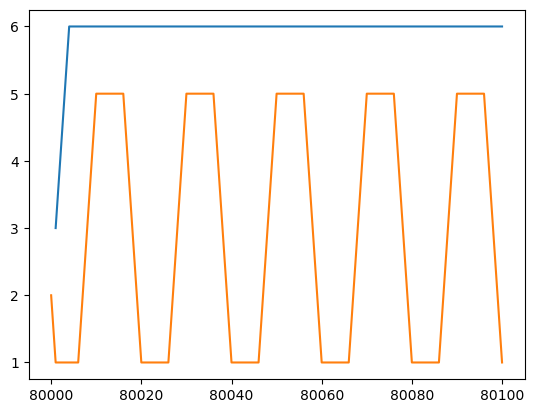

training timestamps 1000
(900, 57) (900, 1)
Epoch 01 | train MSE 0.175423 | val MSE 0.124412
Epoch 02 | train MSE 0.098915 | val MSE 0.033474
Epoch 03 | train MSE 0.065102 | val MSE 0.017163
Epoch 04 | train MSE 0.063506 | val MSE 0.016087
Epoch 05 | train MSE 0.061691 | val MSE 0.017953
Epoch 06 | train MSE 0.059964 | val MSE 0.017354
Epoch 07 | train MSE 0.066216 | val MSE 0.017425
Epoch 08 | train MSE 0.056330 | val MSE 0.018360
Epoch 09 | train MSE 0.054824 | val MSE 0.017454
Epoch 10 | train MSE 0.063647 | val MSE 0.018773
Epoch 11 | train MSE 0.050441 | val MSE 0.019614
Epoch 12 | train MSE 0.046481 | val MSE 0.019729
Epoch 13 | train MSE 0.043581 | val MSE 0.020704
Epoch 14 | train MSE 0.041340 | val MSE 0.020039
Epoch 15 | train MSE 0.038268 | val MSE 0.020124
Epoch 16 | train MSE 0.036252 | val MSE 0.022081
Epoch 17 | train MSE 0.034546 | val MSE 0.021051
Epoch 18 | train MSE 0.032120 | val MSE 0.023505
Epoch 19 | train MSE 0.029448 | val MSE 0.022880
Epoch 20 | train MSE 0.02

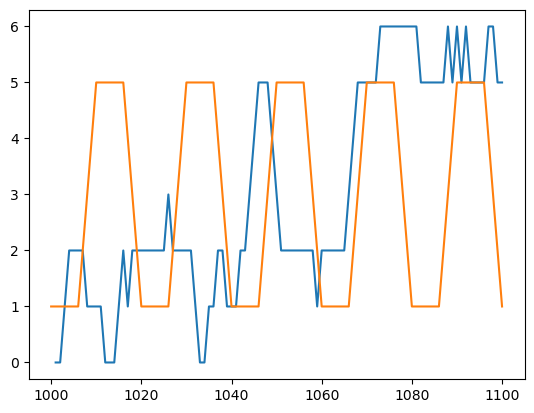

training timestamps 5000
(4500, 57) (4500, 1)
Epoch 01 | train MSE 0.100818 | val MSE 0.041410
Epoch 02 | train MSE 0.063937 | val MSE 0.040378
Epoch 03 | train MSE 0.062479 | val MSE 0.039762
Epoch 04 | train MSE 0.059566 | val MSE 0.039497
Epoch 05 | train MSE 0.057440 | val MSE 0.040390
Epoch 06 | train MSE 0.054450 | val MSE 0.041725
Epoch 07 | train MSE 0.051698 | val MSE 0.040742
Epoch 08 | train MSE 0.048674 | val MSE 0.041364
Epoch 09 | train MSE 0.046210 | val MSE 0.041958
Epoch 10 | train MSE 0.041743 | val MSE 0.043230
Epoch 11 | train MSE 0.038173 | val MSE 0.046560
Epoch 12 | train MSE 0.034891 | val MSE 0.047273
Epoch 13 | train MSE 0.032749 | val MSE 0.047364
Epoch 14 | train MSE 0.029391 | val MSE 0.047133
Epoch 15 | train MSE 0.028301 | val MSE 0.049542
Epoch 16 | train MSE 0.026427 | val MSE 0.047205
Epoch 17 | train MSE 0.025983 | val MSE 0.053813
Epoch 18 | train MSE 0.024038 | val MSE 0.049414
Epoch 19 | train MSE 0.023618 | val MSE 0.054302
Epoch 20 | train MSE 0.

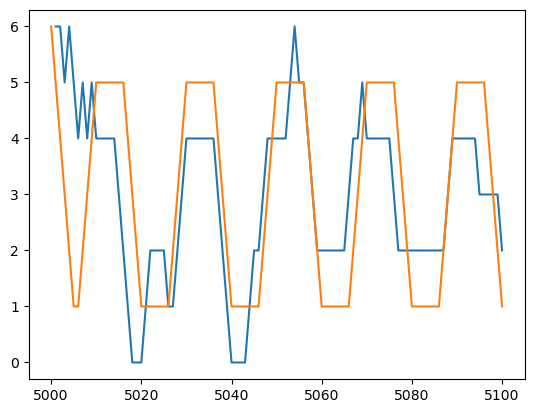

training timestamps 10000
(9000, 57) (9000, 1)
Epoch 01 | train MSE 0.090432 | val MSE 0.074794
Epoch 02 | train MSE 0.077222 | val MSE 0.074794
Epoch 03 | train MSE 0.077469 | val MSE 0.074794
Epoch 04 | train MSE 0.077914 | val MSE 0.074794
Epoch 05 | train MSE 0.077436 | val MSE 0.074794
Epoch 06 | train MSE 0.078076 | val MSE 0.074794
Epoch 07 | train MSE 0.077218 | val MSE 0.074794
Epoch 08 | train MSE 0.077962 | val MSE 0.074794
Epoch 09 | train MSE 0.076773 | val MSE 0.074794
Epoch 10 | train MSE 0.076914 | val MSE 0.074794
Epoch 11 | train MSE 0.076345 | val MSE 0.074794
Epoch 12 | train MSE 0.077456 | val MSE 0.074794
Epoch 13 | train MSE 0.077436 | val MSE 0.074794
Epoch 14 | train MSE 0.077419 | val MSE 0.074794
Epoch 15 | train MSE 0.076358 | val MSE 0.074794
Epoch 16 | train MSE 0.076644 | val MSE 0.074794
Epoch 17 | train MSE 0.077248 | val MSE 0.074794
Epoch 18 | train MSE 0.077609 | val MSE 0.074794
Epoch 19 | train MSE 0.077251 | val MSE 0.074794
Epoch 20 | train MSE 0

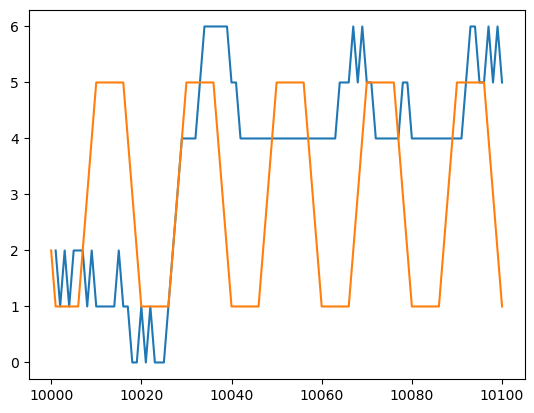

training timestamps 20000
(18000, 57) (18000, 1)
Epoch 01 | train MSE 0.083208 | val MSE 0.070709
Epoch 02 | train MSE 0.075713 | val MSE 0.070709
Epoch 03 | train MSE 0.076337 | val MSE 0.070709
Epoch 04 | train MSE 0.075785 | val MSE 0.070709
Epoch 05 | train MSE 0.075206 | val MSE 0.070709
Epoch 06 | train MSE 0.075153 | val MSE 0.070709
Epoch 07 | train MSE 0.075621 | val MSE 0.070709
Epoch 08 | train MSE 0.074558 | val MSE 0.070709
Epoch 09 | train MSE 0.074210 | val MSE 0.070709
Epoch 10 | train MSE 0.076107 | val MSE 0.070709
Epoch 11 | train MSE 0.075694 | val MSE 0.070709
Epoch 12 | train MSE 0.073973 | val MSE 0.070709
Epoch 13 | train MSE 0.075623 | val MSE 0.070709
Epoch 14 | train MSE 0.074981 | val MSE 0.070709
Epoch 15 | train MSE 0.074785 | val MSE 0.070709
Epoch 16 | train MSE 0.073836 | val MSE 0.070709
Epoch 17 | train MSE 0.075488 | val MSE 0.070709
Epoch 18 | train MSE 0.074848 | val MSE 0.070709
Epoch 19 | train MSE 0.074140 | val MSE 0.070709
Epoch 20 | train MSE

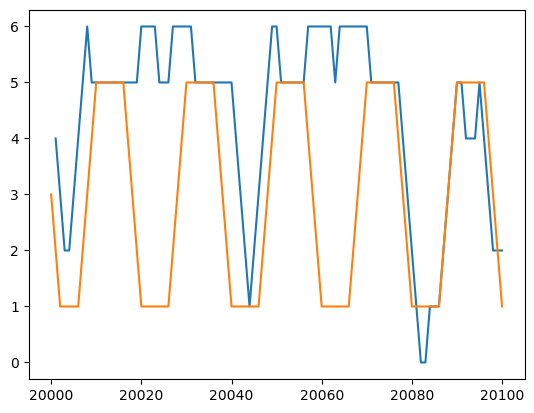

training timestamps 40000
(36000, 57) (36000, 1)
Epoch 01 | train MSE 0.077337 | val MSE 0.084512
Epoch 02 | train MSE 0.075270 | val MSE 0.084512
Epoch 03 | train MSE 0.074769 | val MSE 0.084512
Epoch 04 | train MSE 0.074558 | val MSE 0.084512
Epoch 05 | train MSE 0.074502 | val MSE 0.084512
Epoch 06 | train MSE 0.075506 | val MSE 0.084512
Epoch 07 | train MSE 0.074714 | val MSE 0.084512
Epoch 08 | train MSE 0.074463 | val MSE 0.084512
Epoch 09 | train MSE 0.074870 | val MSE 0.084512
Epoch 10 | train MSE 0.074436 | val MSE 0.084512
Epoch 11 | train MSE 0.074764 | val MSE 0.084512
Epoch 12 | train MSE 0.074660 | val MSE 0.084512
Epoch 13 | train MSE 0.074751 | val MSE 0.084512
Epoch 14 | train MSE 0.074753 | val MSE 0.084512
Epoch 15 | train MSE 0.074520 | val MSE 0.084512
Epoch 16 | train MSE 0.074944 | val MSE 0.084512
Epoch 17 | train MSE 0.074416 | val MSE 0.084512
Epoch 18 | train MSE 0.074436 | val MSE 0.084512
Epoch 19 | train MSE 0.074479 | val MSE 0.084512
Epoch 20 | train MSE

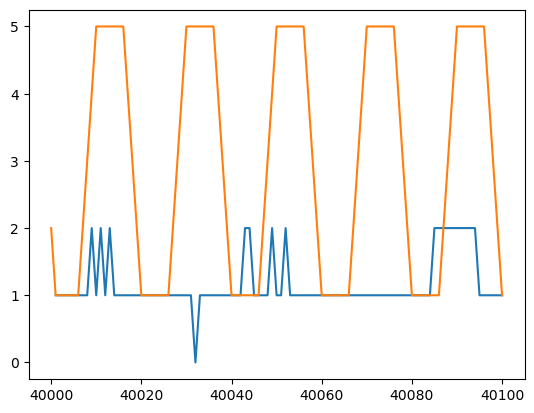

training timestamps 80000
(72000, 57) (72000, 1)
Epoch 01 | train MSE 0.078508 | val MSE 0.073697
Epoch 02 | train MSE 0.076877 | val MSE 0.073697
Epoch 03 | train MSE 0.076774 | val MSE 0.073697
Epoch 04 | train MSE 0.076793 | val MSE 0.073697
Epoch 05 | train MSE 0.076890 | val MSE 0.073697
Epoch 06 | train MSE 0.076820 | val MSE 0.073697
Epoch 07 | train MSE 0.076735 | val MSE 0.073697
Epoch 08 | train MSE 0.076798 | val MSE 0.073697
Epoch 09 | train MSE 0.076850 | val MSE 0.073697
Epoch 10 | train MSE 0.076882 | val MSE 0.073697
Epoch 11 | train MSE 0.076794 | val MSE 0.073697
Epoch 12 | train MSE 0.076769 | val MSE 0.073697
Epoch 13 | train MSE 0.076849 | val MSE 0.073697
Epoch 14 | train MSE 0.076828 | val MSE 0.073697
Epoch 15 | train MSE 0.076757 | val MSE 0.073697
Epoch 16 | train MSE 0.076818 | val MSE 0.073697
Epoch 17 | train MSE 0.076715 | val MSE 0.073697
Epoch 18 | train MSE 0.076783 | val MSE 0.073697
Epoch 19 | train MSE 0.076822 | val MSE 0.073697
Epoch 20 | train MSE

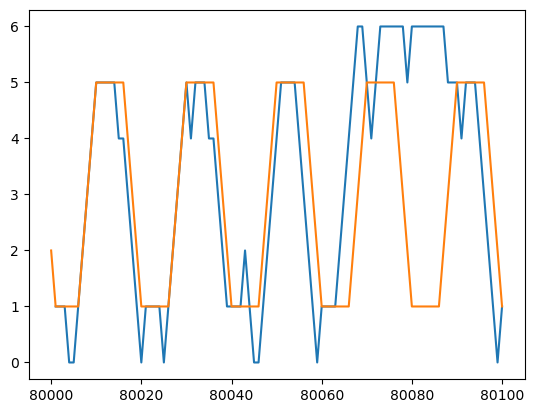

In [ ]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
normalizer = 7 
for rep in np.arange(10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        T_val = int(0.1*T)
        T_initial = T - T_val
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T)

        X_train = new_state_oh[:T_initial,:]
        Y_train = np.array(prewards[:T_initial]).reshape(-1,1)/ normalizer 

        X_val = new_state_oh[T_initial:T,:]
        Y_val = np.array(prewards[T_initial:T]).reshape(-1,1)/ normalizer
        print(X_train.shape,Y_train.shape)

        epochs = 600
        weight_decay = 1e-5
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            epochs = 500
            # hidden_layers = (192,128)
        elif T_initial == 10000:
            learning_rate = 3e-4
            batch_size_train = 128
            # hidden_layers = (512,256)
        elif T_initial == 20000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            learning_rate = 3e-4
            batch_size_train = 256
            hidden_layers = (512,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        
        batch_size_val = T_val

        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*normalizer
                prewards_pred[:,i] = pred_val
            # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/NN_Yuxin/NN_SameStructure_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



In [49]:
current_state = states[T,0]
future_states = [current_state.item()]
# print(current_state)
irewards_test = []
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    prewards_pred = np.zeros((n_paths,  t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        pred_val = predict(model_reg, features)*normalizer
        prewards_pred[:,i] = pred_val
    # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
    idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
    best_idx = idx_sorted[-1]
    best_path = df_all_paths.iloc[best_idx,:]
    next_state = np.array(best_path)[1]
    future_states.append(next_state.item())
    irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
    current_state = next_state
# print(T,future_states,len(future_states))
FUTURE_STATE.append(future_states)

irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_future,100,gamma)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
# plt.plot(np.arange(T+1,T+101),future_states[1:])
# plt.plot(np.arange(T,T+101),path)
# plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
# np.savez(
#     f"../results/PVFM/NN_Yuxin/NN_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
#     future_states =FUTURE_STATE_arr
#     )



/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_84008/3527481909.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prewards_pred[:,i] = pred_val


1.684586217699661
